In [1]:
from preamble import *

2025-09-03 15:58:00,144 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


# Read Data
## Save as Rainbows

In [2]:
G102_extracted_spec = '/Users/wiwa8630/Desktop/Projects/AUMic_15836/PACMAN/G102/run_2024-10-19_12-00-36_AUMic_G102/extracted_lc/2024-10-19_12-05-03/lc_spec.txt'
G141_extracted_spec = '/Users/wiwa8630/Desktop/Projects/AUMic_15836/PACMAN/G141/run_2024-10-19_12-11-10_AUMic_G141/extracted_lc/2024-10-19_12-30-32/lc_spec.txt'

In [3]:
# Open the .txt file using astropy's Table.read
F21_table = Table.read(G141_extracted_spec, format='ascii')
S22_table = Table.read(G102_extracted_spec, format='ascii')

# Split the dataset based on scan value
F21_forward_scan = F21_table[F21_table['scan'] == 0.0]
F21_reverse_scan = F21_table[F21_table['scan'] == 1.0]
S22_forward_scan = S22_table[S22_table['scan'] == 0.0]
S22_reverse_scan = S22_table[S22_table['scan'] == 1.0]

  0%|          | 0/162 [00:00<?, ?it/s]

Successfully saved Rainbow object for F21 Forward


  0%|          | 0/162 [00:00<?, ?it/s]

Successfully saved Rainbow object for F21 Reverse


  0%|          | 0/160 [00:00<?, ?it/s]

Successfully saved Rainbow object for S22 Forward


  0%|          | 0/160 [00:00<?, ?it/s]

Successfully saved Rainbow object for S22 Reverse


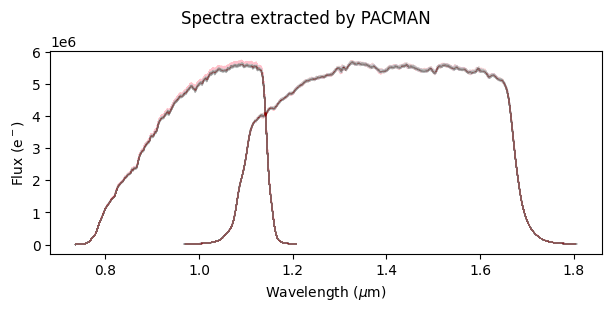

In [4]:
fig, ax = plt.subplots(1,1,figsize=(6,3))

for visit in ['F21','S22']:    
    for direction in ['Forward','Reverse']:
        
        if visit=='F21':
            if direction =='Forward':
                table = F21_forward_scan
                col='darkred'
            if direction =='Reverse':        
                table = F21_reverse_scan
                col='pink'
        
        if visit=='S22':
            if direction =='Forward':
                table = S22_forward_scan
                col='darkred'
            if direction =='Reverse':  
                table = S22_reverse_scan
                col='pink'
                
        wavelength = table['template_waves'].data/1e4 * u.micron  # Wavelength
        flux = table['spec_opt'].data * u.electron      # Spectrum
        var = table['var_opt'].data     # Variance
        err = np.sqrt(var) * u.electron
        bjd_times = table['t_bjd'].data * u.day       # Times converted from MJD
        
        unique_times = np.unique(bjd_times)
        unique_wavelengths = np.unique(wavelength)
        
        flux_list = [None]*len(unique_times)
        err_list = [None]*len(unique_times)
        wave_list = [None]*len(unique_times)
        
        i = 0
        for t_i in unique_times:
            
            this_times_wavelengths = wavelength[bjd_times == t_i]
            this_times_fluxes = flux[bjd_times == t_i]
            this_times_errors = err[bjd_times == t_i]
            
            wave_list[i] = this_times_wavelengths
            flux_list[i] = this_times_fluxes
            err_list[i] = this_times_errors
                
            ax.errorbar(this_times_wavelengths, this_times_fluxes, yerr=this_times_errors, alpha=0.005,color=col)
            i += 1

        stacked_flux = np.stack(flux_list, axis = 1)
        stacked_err = np.stack(err_list, axis = 1)
        stacked_wave = np.stack(wave_list, axis = 1)
        
        pacman_rainbow = Rainbow(wavelength = np.nanmedian(stacked_wave, axis=1),
                          time = unique_times,
                          flux = stacked_flux,
                          uncertainty = stacked_err)
        # Save the unaltered extracted spec
        pacman_rainbow.save(f'../data/{visit}_{direction}_unaltered_pacman_spec.rainbow.npy')

        # In the event that the wavelength arrays are not identical, this will correct that
        pacman_rainbow.fluxlike["wavelength_2d"] = stacked_wave
        aligned = pacman_rainbow.align_wavelengths()      
        aligned.save(f'../data/{visit}_{direction}_aligned_pacman_spec.rainbow.npy')
        print(f'Successfully saved Rainbow object for {visit} {direction}')
        
fig.suptitle(f'Spectra extracted by PACMAN')
# ax.set_title('S22')
# ax.set_title('F21')
# plt.yscale('log')
plt.ylabel(r'Flux (e$^-$)')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.savefig(f'../figs/{visit}_pacman_spectra.png',dpi=300)
plt.show()

# Examine the spectroscopic light curves we just saved with Chromatic

🌈🤖 The time scale for this rainbow is '?',
and there are 162 time centers and
162 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



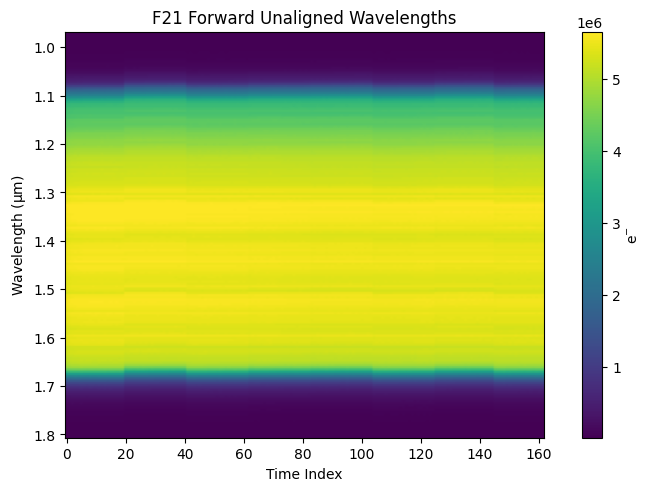

🌈🤖 The time scale for this rainbow is '?',
and there are 162 time centers and
162 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



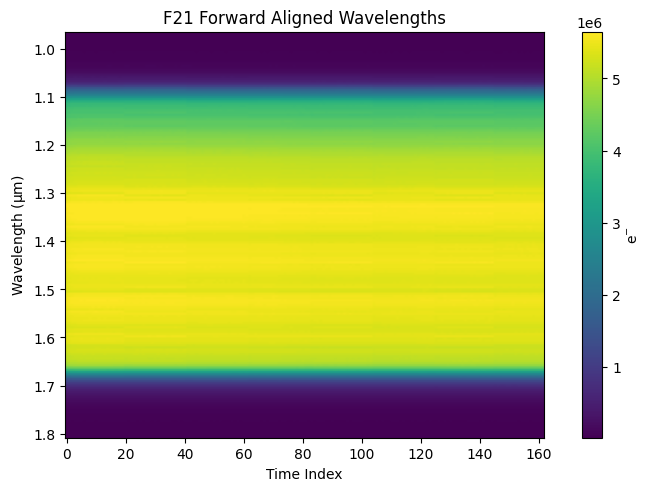

🌈🤖 The time scale for this rainbow is '?',
and there are 162 time centers and
162 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



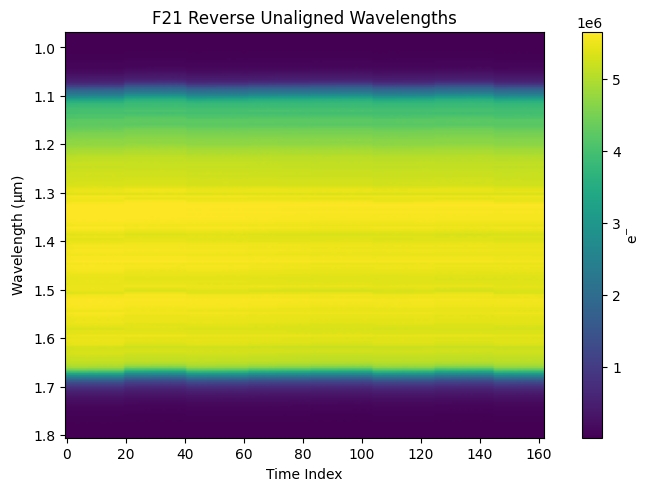

🌈🤖 The time scale for this rainbow is '?',
and there are 162 time centers and
162 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



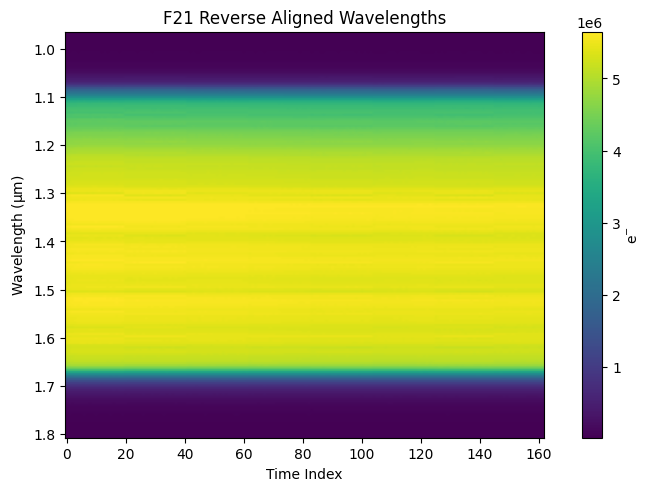

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



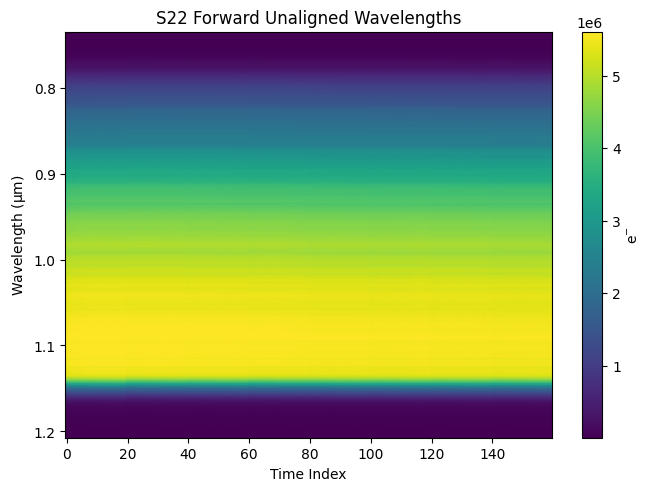

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



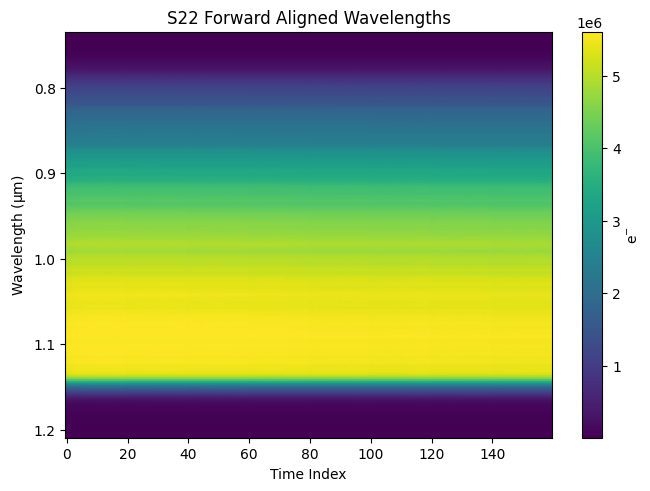

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



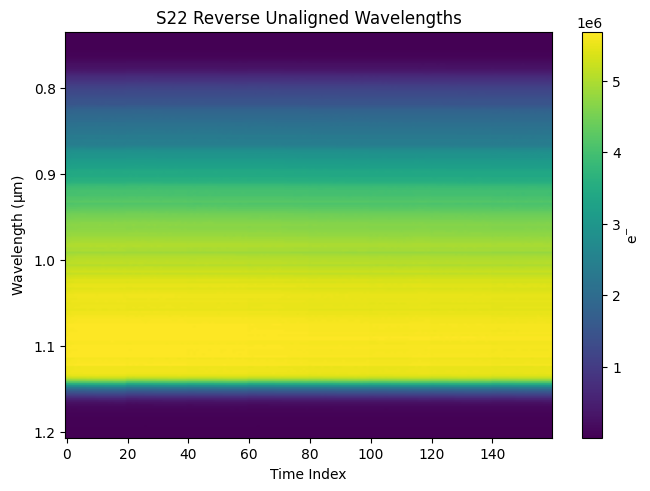

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



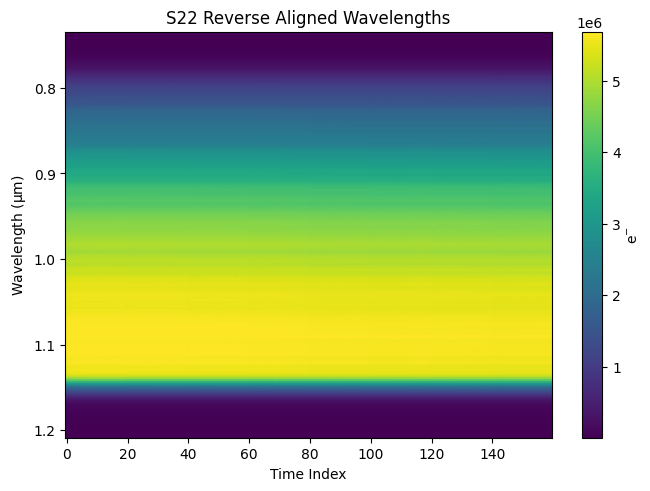

<Figure size 640x480 with 0 Axes>

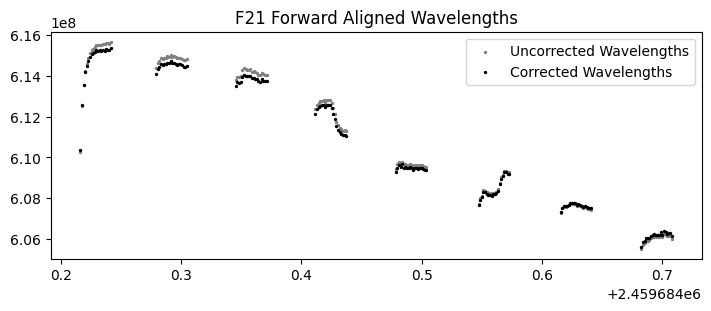

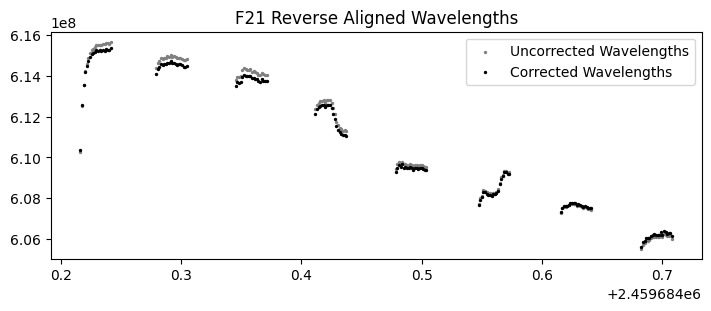

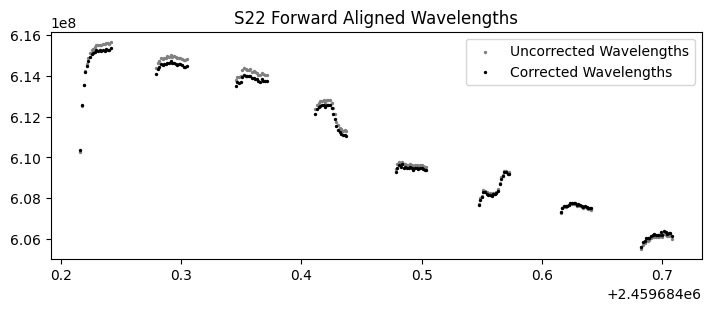

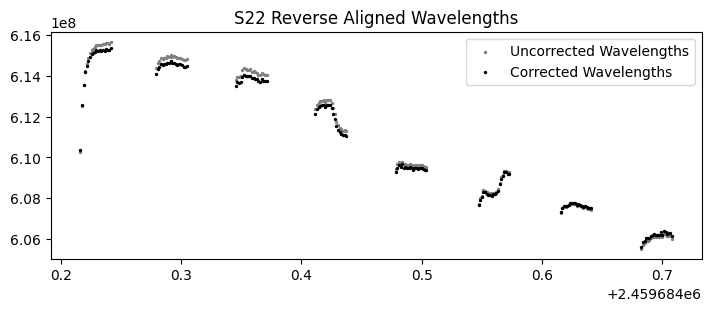

In [5]:
for visit in ['F21','S22']:
    
    for direction in ['Forward','Reverse']:
                
        unaltered_rainbow = read_rainbow(f'../data/{visit}_{direction}_unaltered_pacman_spec.rainbow.npy')
        unaltered_rainbow.imshow()
        plt.title(f'{visit} {direction} Unaligned Wavelengths')
        plt.savefig(f'../figs/{visit}_{direction}_pacman_unaligned_imshow.png',dpi=600)
        plt.show()
        plt.clf()

        aligned_rainbow = read_rainbow(f'../data/{visit}_{direction}_aligned_pacman_spec.rainbow.npy')
        aligned_rainbow.imshow()
        plt.title(f'{visit} {direction} Aligned Wavelengths')
        plt.savefig(f'../figs/{visit}_{direction}_pacman_aligned_imshow.png',dpi=600)
        plt.show()
        plt.clf()

for visit in ['F21','S22']:
    
    for direction in ['Forward','Reverse']:

        plt.figure(figsize=(7,3))
        
        unaltered_whitelight_flux = np.nansum(unaltered_rainbow.flux, axis = 0)
        plt.title(f'{visit} {direction} Unaligned Wavelengths')
        plt.scatter(unaltered_rainbow.time, unaltered_whitelight_flux,label='Uncorrected Wavelengths',
                    color='gray',s=2)

        aligned_whitelight_flux = np.nansum(aligned_rainbow.flux, axis = 0)
        aligned_whitelight_err = np.nansum(aligned_rainbow.uncertainty, axis = 0)
        plt.title(f'{visit} {direction} Aligned Wavelengths')
        plt.scatter(aligned_rainbow.time, aligned_whitelight_flux, label='Corrected Wavelengths',
                    color='black',s=2)

        plt.legend()
        plt.savefig(f'../figs/{visit}_{direction}_pacman_whitelightcurve.png',dpi=600)
        plt.show()        

# Trim the edges of each spectrum, save as a new object

F21 Forward



  0%|          | 0/182 [00:00<?, ?it/s]

F21 Reverse



  0%|          | 0/182 [00:00<?, ?it/s]

S22 Forward



  0%|          | 0/193 [00:00<?, ?it/s]

S22 Reverse



  0%|          | 0/193 [00:00<?, ?it/s]

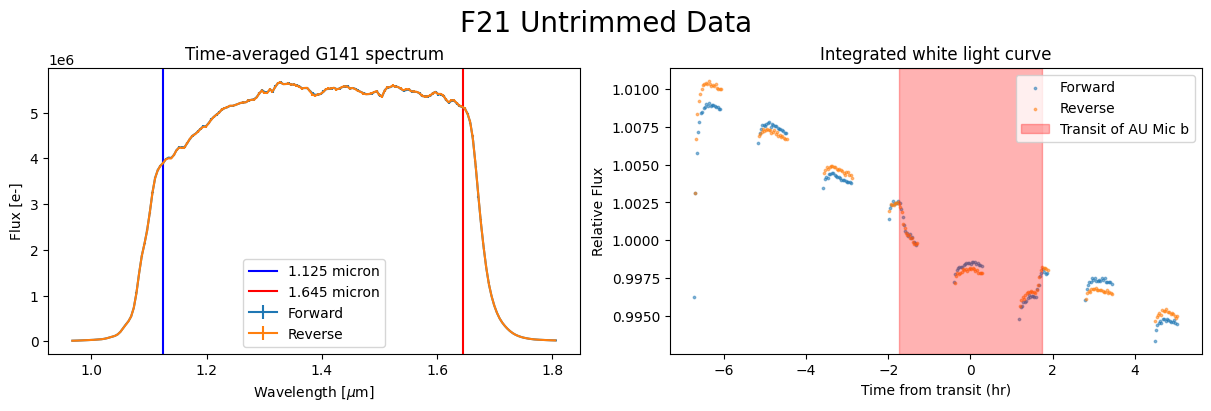

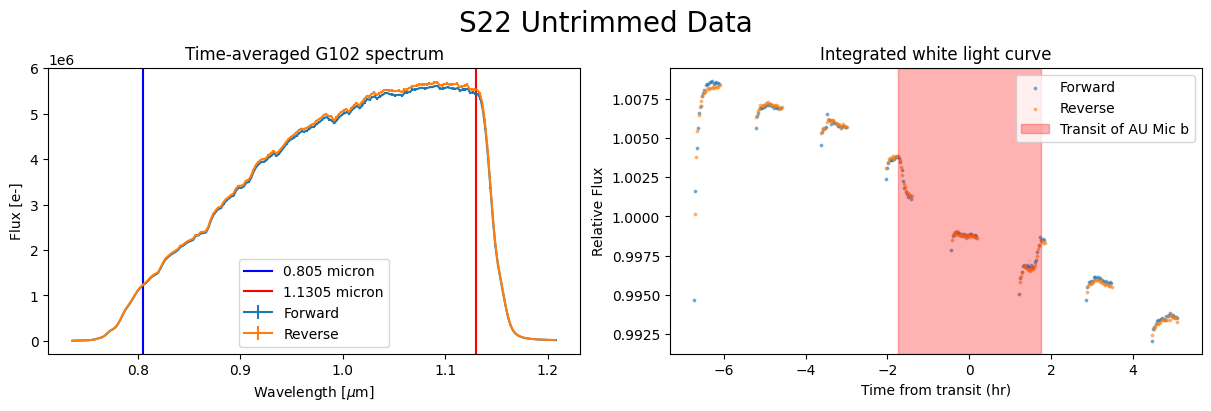

In [11]:
for visit in ['F21','S22']:
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

    for direction in ['Forward','Reverse']:
        print(visit,direction)
        print('')

        'Read in the data from the previous step'
        aligned_rainbow = read_rainbow(f'../data/{visit}_{direction}_aligned_pacman_spec.rainbow.npy')

        'Calculate the average spectrum'
        average_spec = aligned_rainbow.get_average_spectrum()
        average_spec_err = 0.005*average_spec

        visit_data = visits[f'{visit}']        
        grism = visit_data['Grism']
        t0 = visit_data['T0 (BJD_TDB)']
        if visit =='F21':
            wave_lower = 1.125*u.micron # blue-end cutoff for trimming
            wave_upper = 1.645*u.micron # red-end cutoff for trimming
            grism = 'G141'

        if visit =='S22':
            wave_lower = 0.805*u.micron # blue-end cutoff for trimming
            wave_upper = 1.1305*u.micron # red-end cutoff for trimming
            grism = 'G102'
        
        'Calculate the white light curve'
        white_light_curve = np.nansum(aligned_rainbow.flux, axis=0)
        white_light_curve_err = 30e-6*white_light_curve
        
        'Plot'
        ax1.errorbar(aligned_rainbow.wavelength, average_spec, yerr=average_spec_err,label=f'{direction}')
        ax2.scatter((aligned_rainbow.time.value-t0.value)*24, white_light_curve/np.nanmean(white_light_curve[22:]), s=3,alpha=0.5, label=f'{direction}')

    # ax1.axhline(0.25*np.nanmax(average_spec.value),label=r'25$\%$ Peak Fluence')
    ax1.axvline(wave_lower.value,label=f'{wave_lower.value} micron',color='blue')
    ax1.axvline(wave_upper.value,label=f'{wave_upper.value} micron',color='red')
    ax1.legend()
    ax1.set_title(f'Time-averaged {grism} spectrum')
    ax1.set_xlabel(r'Wavelength [$\mu$m]')
    ax1.set_ylabel('Flux [e-]')
    
    ax2.axvspan(-1.75, 1.75, alpha=0.3,color='r',label='Transit of AU Mic b')
    # ax2.axvspan((first_orbit_start.value-t0.value)*24, (first_orbit_end.value-t0.value)*24,label=f'First Orbit',alpha=0.3,zorder=-100,color='gray',linestyle='')
    ax2.legend()
    ax2.set_title(f'Integrated white light curve')
    ax2.set_xlabel(r'Time from transit (hr)')
    ax2.set_ylabel('Relative Flux')
    
    plt.suptitle(f'{visit} Untrimmed Data',size=20)
    plt.savefig(f"../figs/{visit}_untrimmed_pacman_data.png",dpi=300)

F21 Forward



  0%|          | 0/112 [00:00<?, ?it/s]

🌈🤖 The time scale for this rainbow is '?',
and there are 162 time centers and
162 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



F21 Reverse



  0%|          | 0/112 [00:00<?, ?it/s]

...

  0%|          | 0/132 [00:00<?, ?it/s]

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



S22 Reverse



  0%|          | 0/132 [00:00<?, ?it/s]

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



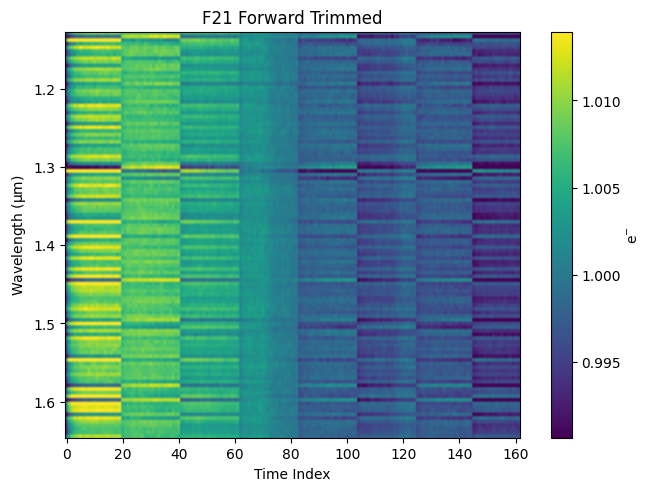

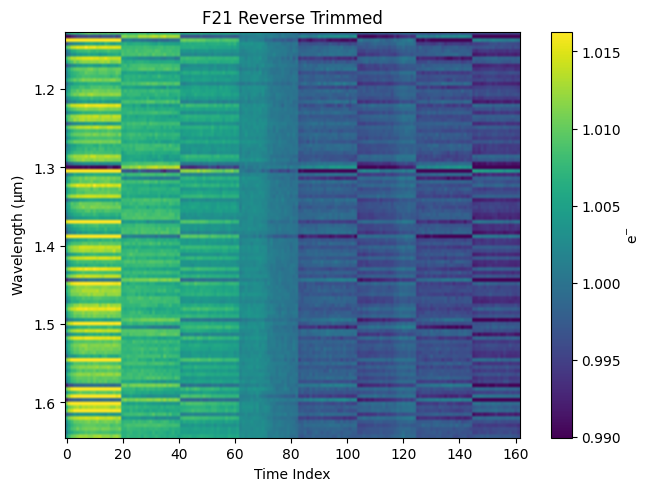

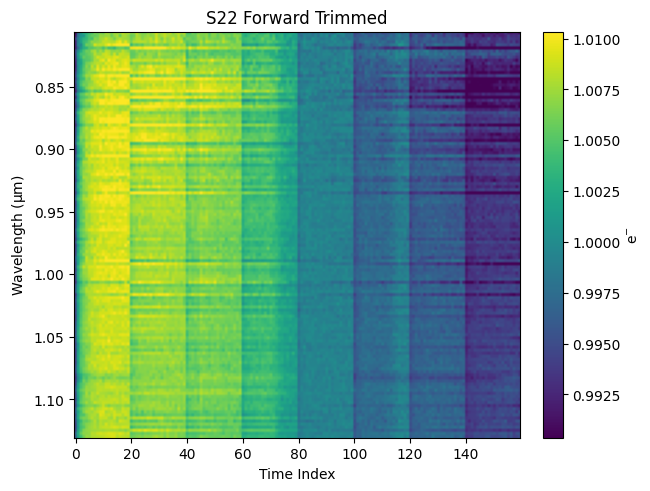

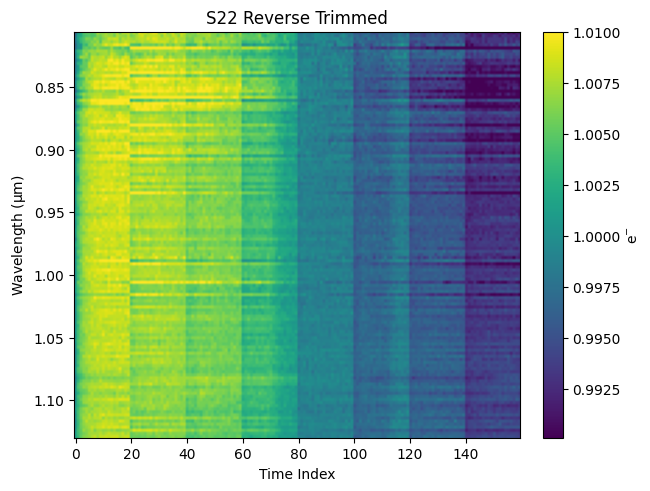

In [12]:
for visit in ['F21','S22']:
    
    # fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

    for direction in ['Forward','Reverse']:
        print(visit,direction)
        print('')
        
        'Load data tables'
        visit_data = visits[f'{visit}']        
        t0 = visit_data['T0 (BJD_TDB)']
       
        if visit =='F21':
            wave_lower = 1.125*u.micron # blue-end cutoff for trimming
            wave_upper = 1.645*u.micron # red-end cutoff for trimming
            grism = 'G141'

        if visit =='S22':
            wave_lower = 0.805*u.micron # blue-end cutoff for trimming
            wave_upper = 1.1305*u.micron # red-end cutoff for trimming
            grism = 'G102'
            
        aligned_rainbow = read_rainbow(f'../data/{visit}_{direction}_aligned_pacman_spec.rainbow.npy')
        wavelength = aligned_rainbow.wavelength
        # if direction == 'Forward':
        #     ref_wavelength = wavelength
        # if direction == 'Reverse':
            # for i in range(len(aligned_rainbow.time.value)):
            #     aligned_rainbow.flux.value[:,i] = bintogrid(x=aligned_rainbow.wavelength.value, y=aligned_rainbow.flux.value[:,i], newx=ref_wavelength.value)['y']
            #     aligned_rainbow.wavelength = ref_wavelength
        
        'Trim the bad wavelengths from the wavelength and flux arrays'
        a = (wave_upper >= wavelength)
        b = (wavelength >= wave_lower)
        ok_wavelengths = (a == b) # trim the edges of each spectrum
        wave = wavelength[ok_wavelengths]    
        _flux = aligned_rainbow.flux[ok_wavelengths,:]
        unc = aligned_rainbow.uncertainty[ok_wavelengths, :]
        time = aligned_rainbow.time

        'Turn the wavelength-trimmed data into a Rainbow object and save to a file to use later'
        trimmed = Rainbow(wavelength=wave, time=aligned_rainbow.time, flux=_flux, uncertainty=unc)
        trimmed.save(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")

        # alter this so that the rainbow is the summed-and-normalized flux with relative uncertainties
        # (Scan combined)

        # trimmed.imshow()
        'Calculate the white light curve'
        white_light_curve = np.nansum(trimmed.flux,axis=0)
        'Calculate the average spectrum'
        average_spec = trimmed.get_average_spectrum()
        average_spec_err = 0.005*average_spec #up to debate how to calculate this
        
        ''' Plot  '''
        # ax1.errorbar(trimmed.wavelength, average_spec, yerr=average_spec_err,label=f'{direction}')
        # ax2.scatter((time-t0)*24, white_light_curve, label=f'{direction}',s=2)

        for i,wavelength in enumerate(trimmed.wavelength.value):
            this_flux = trimmed.flux[i,:]
            normed_flux = this_flux / np.nanmedian(this_flux)
            trimmed.flux[i,:] = normed_flux*u.electron

        plt.figure()
        trimmed.imshow()
        plt.title(f'{visit} {direction} Trimmed')
        plt.savefig(f"../figs/{visit}_{direction}_trimmed_normed_imshow.png",dpi=300)
    
        # plt.figure()
        # trimmed.plot()
        # plt.title(f'{visit} {direction} Trimmed')
        # plt.savefig(f"../figs/{visit}_{direction}_trimmed_speclcs.png",dpi=300)

    # ax1.legend()
    # ax1.set_title(f'Time-averaged {grism} spectrum')
    # ax1.set_xlabel(r'Wavelength [$\mu$m]')
    # ax1.set_ylabel(r'Flux (e$^-$')
    
    # ax2.axvspan(-1.75, 1.75, alpha=0.3,color='r',label='Dur = 3.5 Hr')
    # ax2.legend()
    # ax2.set_title(f'White light curve')
    # ax2.set_xlabel(r'Time from expected mid-transit (hr)')
    # # ax2.set_ylabel(r'Flux (e$^-$')
    
    # # plt.suptitle(f'{visit} Trimmed Data',size=20)
    # plt.savefig(f"../figs/{visit}_processed_data.png",dpi=300)

In [13]:
# S22_bin_edges = np.array([0.786000,0.796020,
#                           0.805850,0.815685,0.825520,0.835350,
#                           0.845190,0.859940,0.869770,0.879605,0.889440,
#                           0.904190,0.916480,0.928770,0.938610,
#                           0.948440,0.958275,0.968110,0.977940,0.985320,0.997610,
#                           1.009900,1.017280,1.027110,1.036945,1.046780,
#                           1.056610,1.066450,1.076280,1.088570,1.100865,1.110700,1.120530,1.133000]) * u.micron

# F21_bin_edges = np.array([1.117475,1.131375,1.145275,1.163805,
#                           1.182335,1.200865,
#                           1.214765,1.251830,1.279625,1.325955,
#                           1.349120,1.390815,1.413980,1.474205,1.520535,1.539065,
#                           1.552965,1.566865,1.585395,1.622455,1.64]) * u.micron

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



S22 | Median relative uncertainty at 0.8071 micron = 626 ppm
S22 | Median relative uncertainty at 0.8095 micron = 614 ppm
S22 | Median relative uncertainty at 0.8120 micron = 600 ppm
S22 | Median relative uncertainty at 0.8145 micron = 590 ppm
S22 | Median relative uncertainty at 0.8169 micron = 583 ppm
S22 | Median relative uncertainty at 0.8194 micron = 577 ppm
S22 | Median relative uncertainty at 0.8218 micron = 558 ppm
S22 | Median relative uncertainty at 0.8243 micron = 540 ppm
S22 | Median relative uncertainty at 0.8267 micron = 526 ppm
S22 | Median relative uncertainty at 0.8292 micron = 519 ppm
S22 | Median relative uncertainty at 0.8317 micron = 513 ppm
S22 | Median relative uncertainty at 0.8341 micron = 508 ppm
S22 | Median relative uncertainty at 0.8366 micron = 504 ppm
S22 | Median relative uncertainty at 0.8390 micron = 498 ppm
S22 | Median relative uncertainty at 0.8415 micron = 490 ppm
S22 | Median relative uncertainty at 0.8440 micron = 487 ppm
S22 | Median relative un

/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_43452/1143806923.py:32: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (5,2))


S22 | Median relative uncertainty at 0.8562 micron = 464 ppm
S22 | Median relative uncertainty at 0.8587 micron = 464 ppm
S22 | Median relative uncertainty at 0.8612 micron = 458 ppm
S22 | Median relative uncertainty at 0.8636 micron = 458 ppm
S22 | Median relative uncertainty at 0.8661 micron = 456 ppm
S22 | Median relative uncertainty at 0.8685 micron = 447 ppm
S22 | Median relative uncertainty at 0.8710 micron = 433 ppm
S22 | Median relative uncertainty at 0.8735 micron = 424 ppm
S22 | Median relative uncertainty at 0.8759 micron = 418 ppm
S22 | Median relative uncertainty at 0.8784 micron = 414 ppm
S22 | Median relative uncertainty at 0.8808 micron = 412 ppm
S22 | Median relative uncertainty at 0.8833 micron = 406 ppm
S22 | Median relative uncertainty at 0.8858 micron = 402 ppm
S22 | Median relative uncertainty at 0.8882 micron = 399 ppm
S22 | Median relative uncertainty at 0.8907 micron = 396 ppm
S22 | Median relative uncertainty at 0.8931 micron = 394 ppm
S22 | Median relative un

🌈🤖 The time scale for this rainbow is '?',
and there are 162 time centers and
162 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



F21 | Median relative uncertainty at 1.1291 micron = 354 ppm
F21 | Median relative uncertainty at 1.1337 micron = 353 ppm
F21 | Median relative uncertainty at 1.1383 micron = 353 ppm
F21 | Median relative uncertainty at 1.1430 micron = 350 ppm
F21 | Median relative uncertainty at 1.1476 micron = 346 ppm
F21 | Median relative uncertainty at 1.1522 micron = 343 ppm
F21 | Median relative uncertainty at 1.1569 micron = 343 ppm
F21 | Median relative uncertainty at 1.1615 micron = 343 ppm
F21 | Median relative uncertainty at 1.1661 micron = 340 ppm
F21 | Median relative uncertainty at 1.1708 micron = 336 ppm
F21 | Median relative uncertainty at 1.1754 micron = 333 ppm
F21 | Median relative uncertainty at 1.1800 micron = 332 ppm
F21 | Median relative uncertainty at 1.1847 micron = 330 ppm
F21 | Median relative uncertainty at 1.1893 micron = 328 ppm
F21 | Median relative uncertainty at 1.1939 micron = 326 ppm
F21 | Median relative uncertainty at 1.1986 micron = 326 ppm
F21 | Median relative un

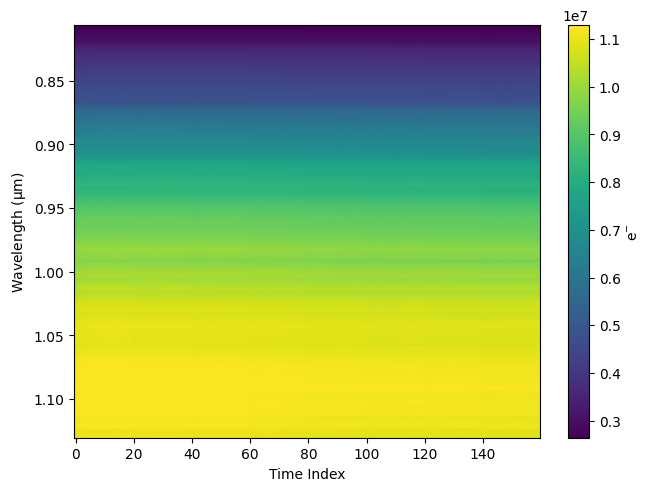

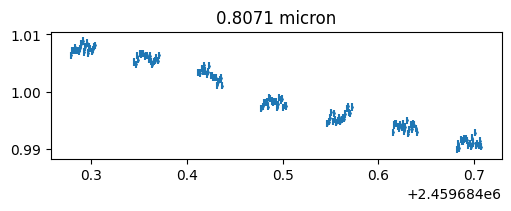

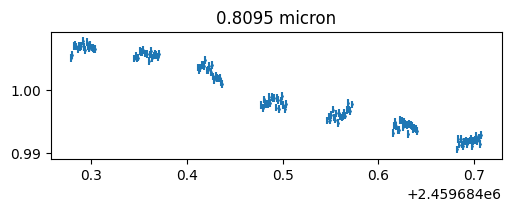

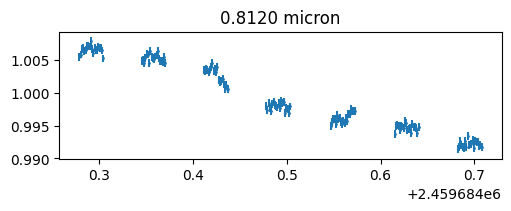

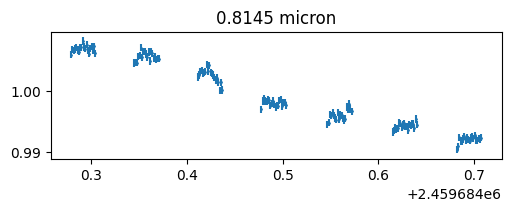

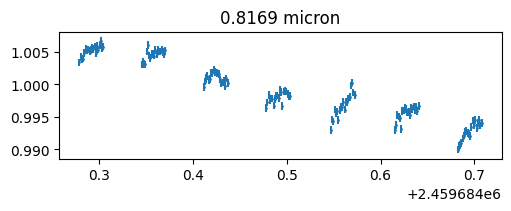

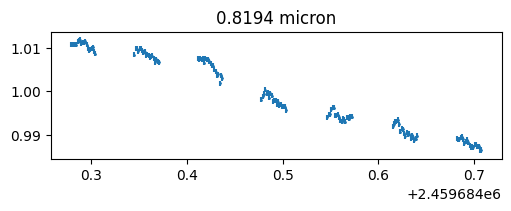

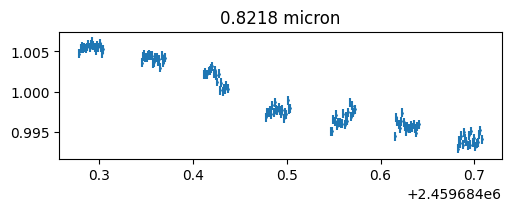

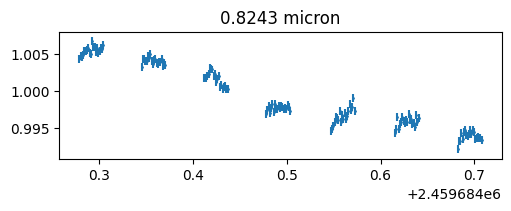

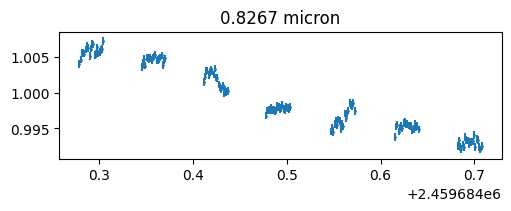

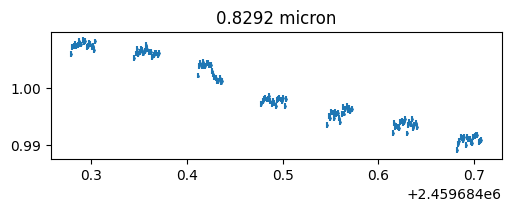

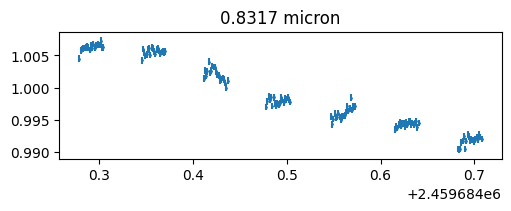

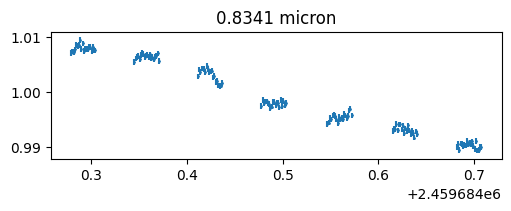

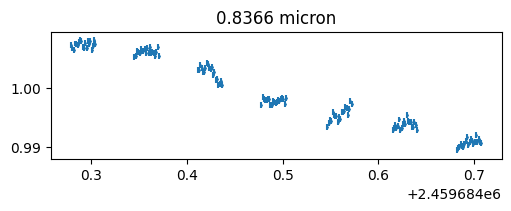

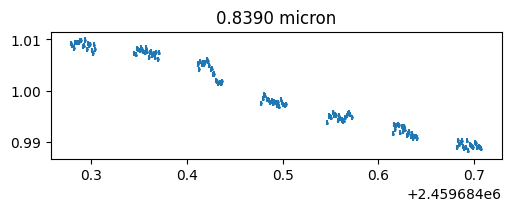

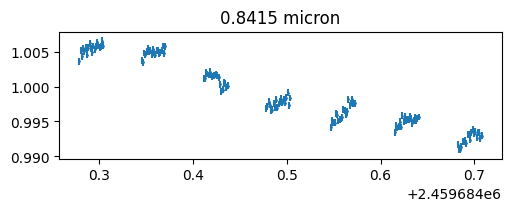

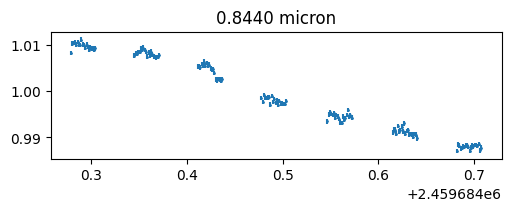

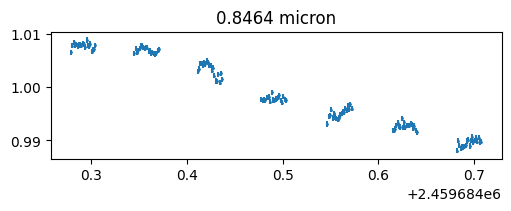

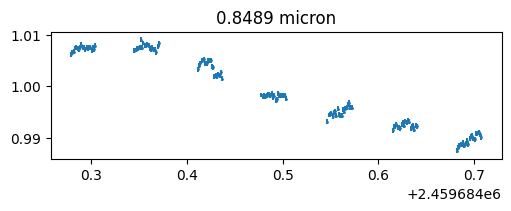

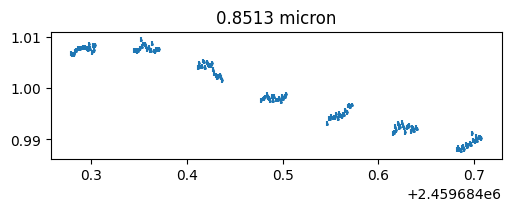

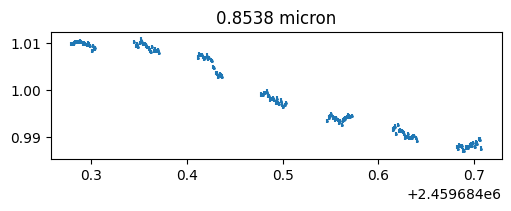

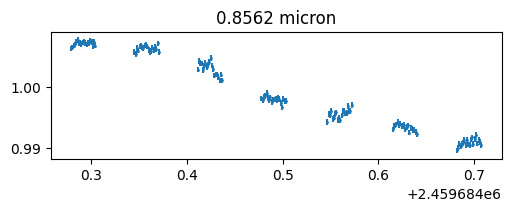

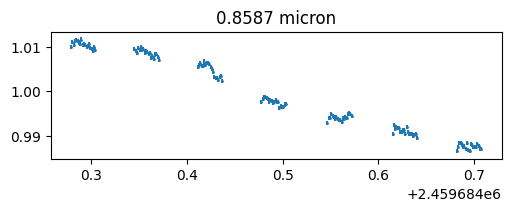

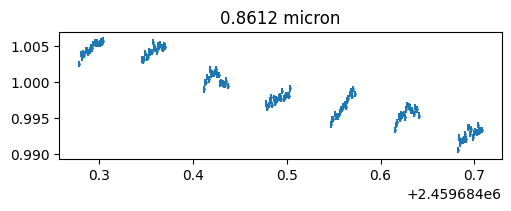

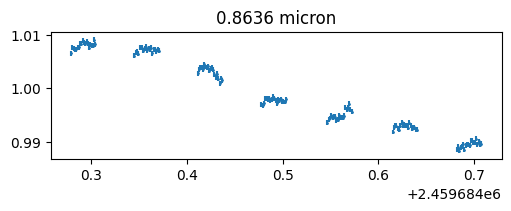

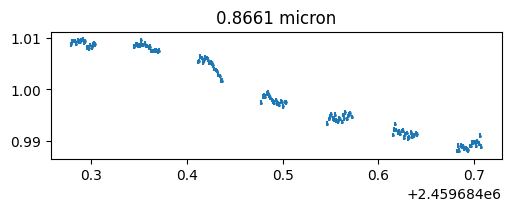

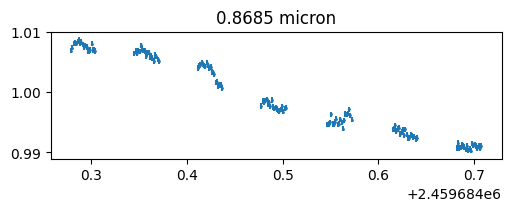

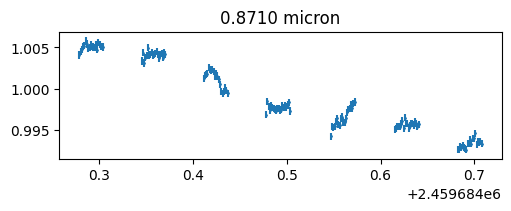

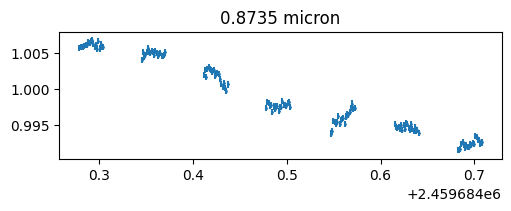

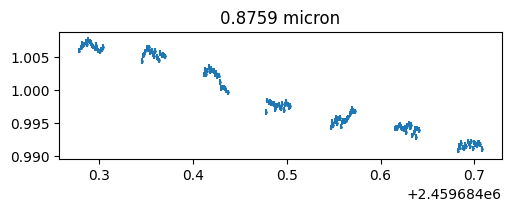

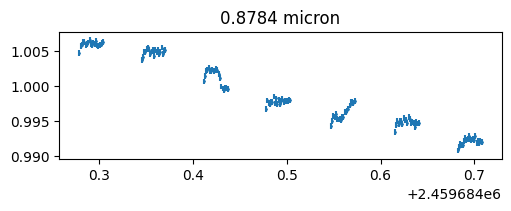

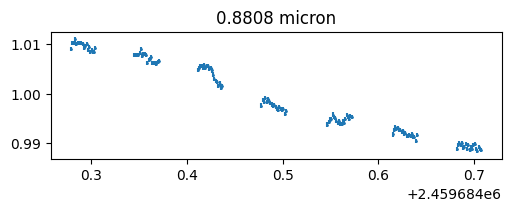

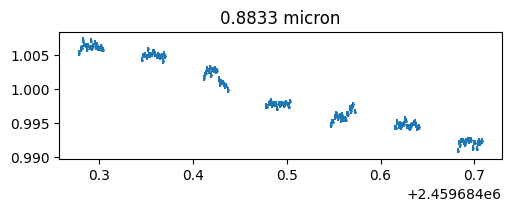

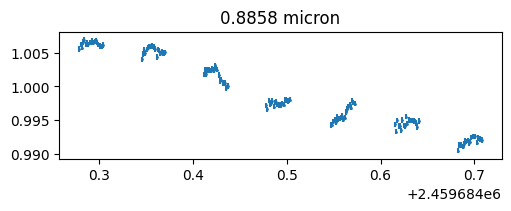

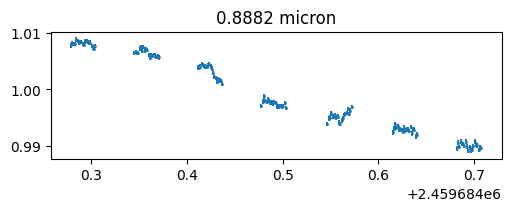

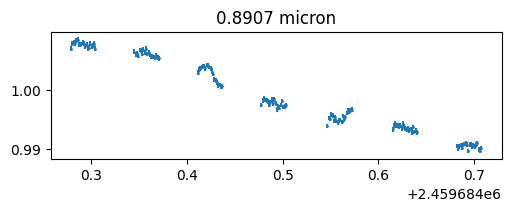

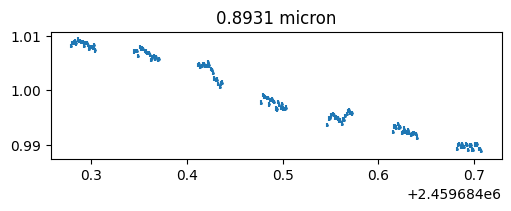

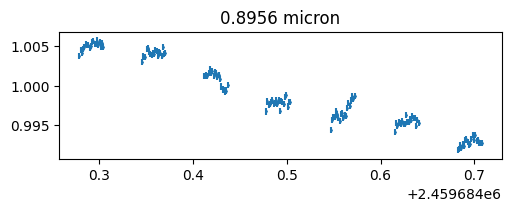

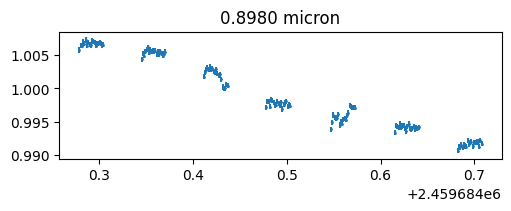

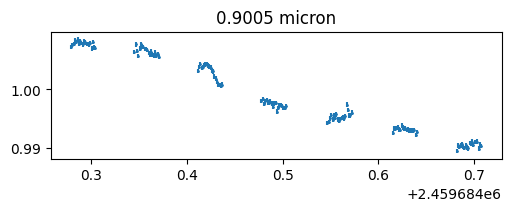

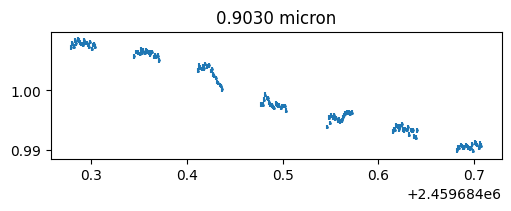

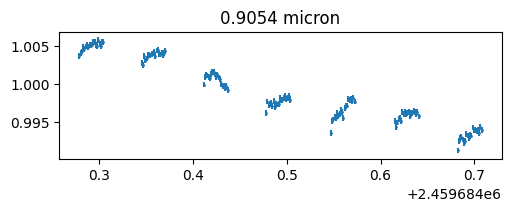

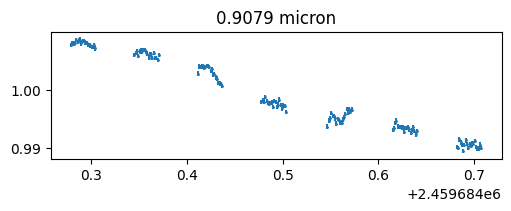

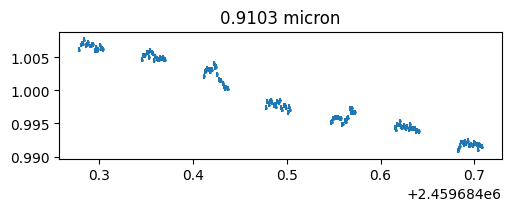

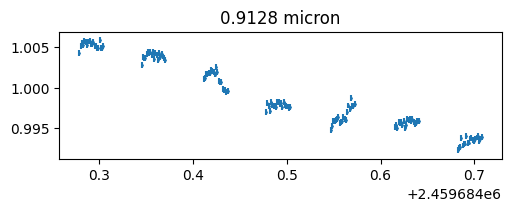

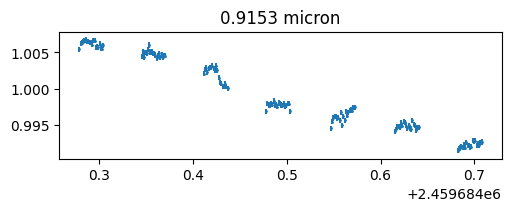

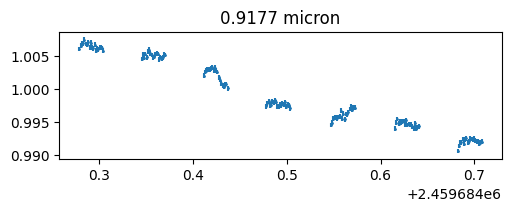

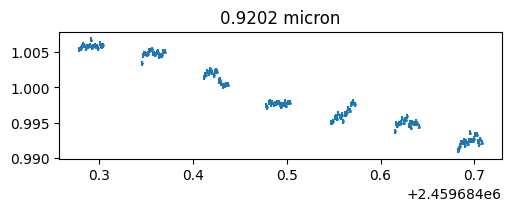

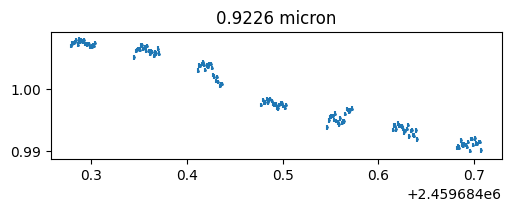

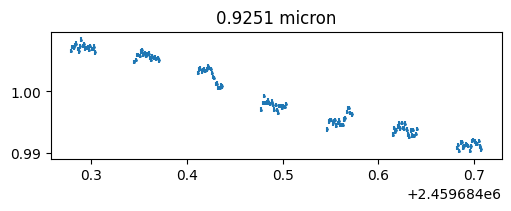

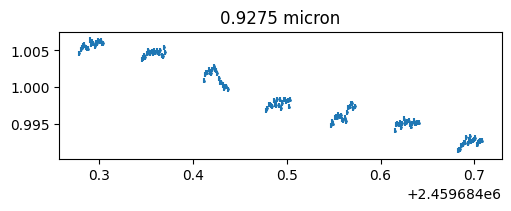

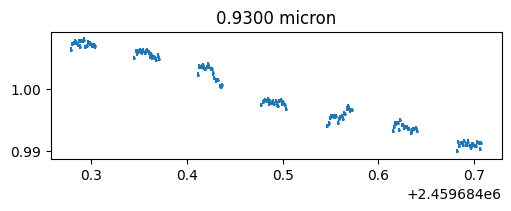

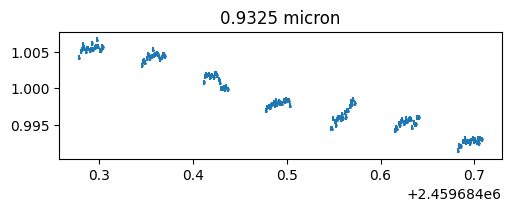

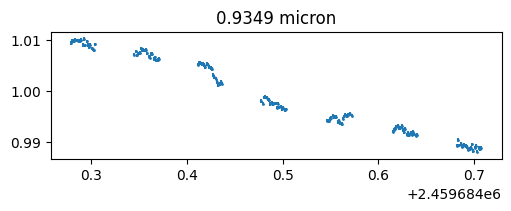

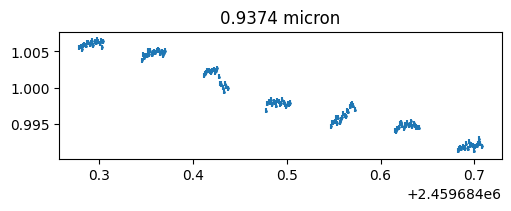

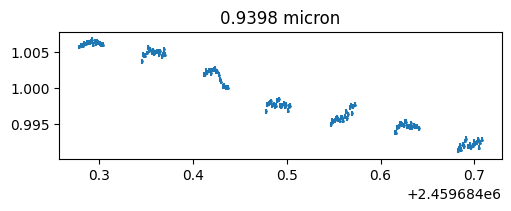

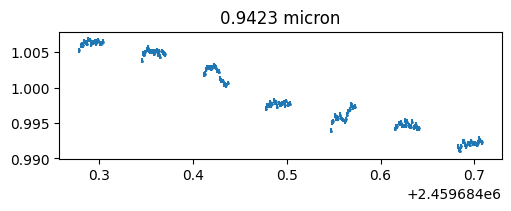

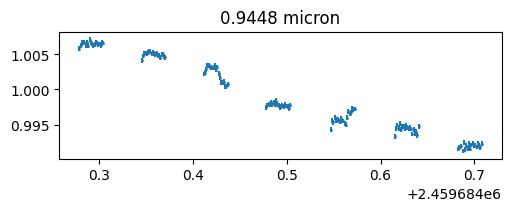

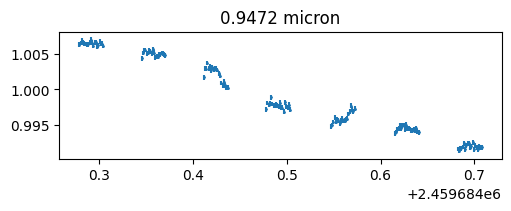

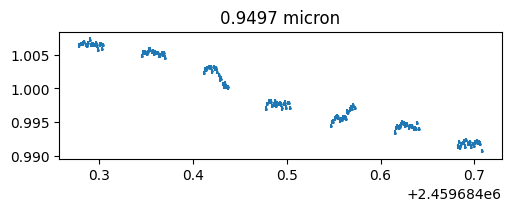

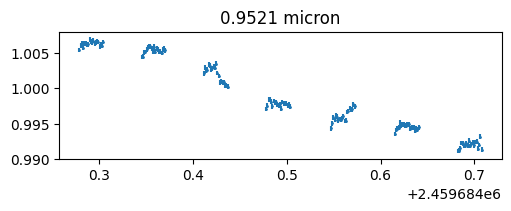

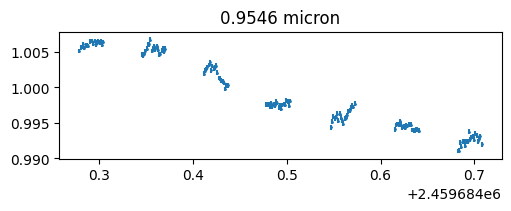

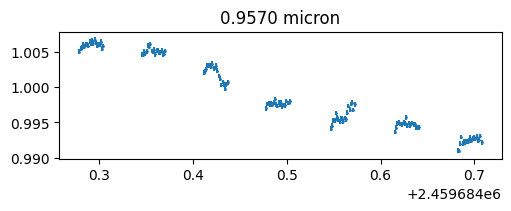

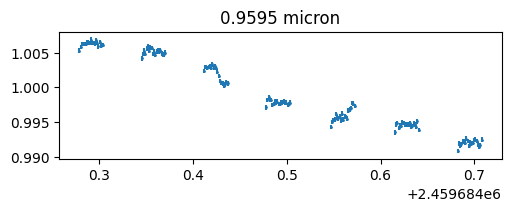

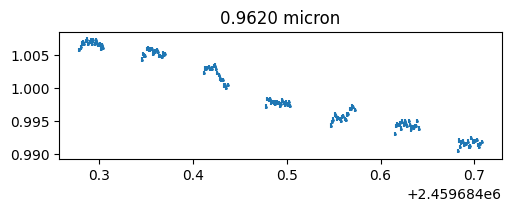

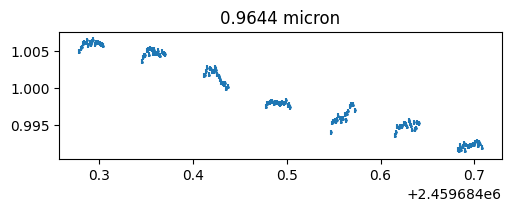

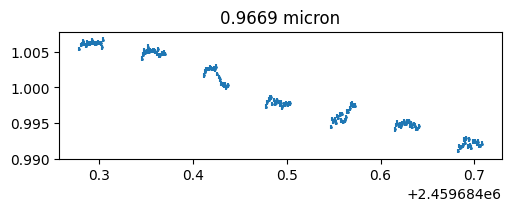

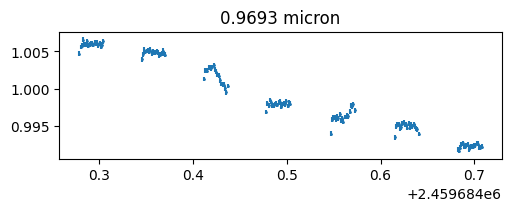

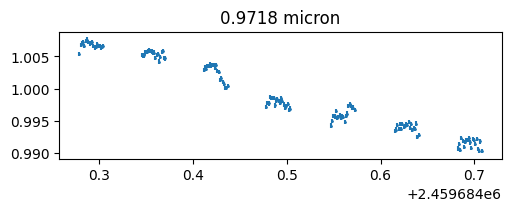

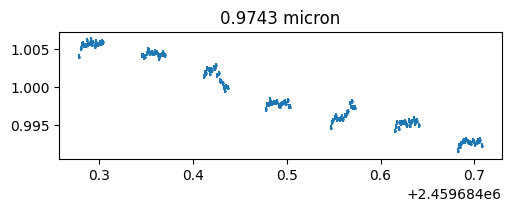

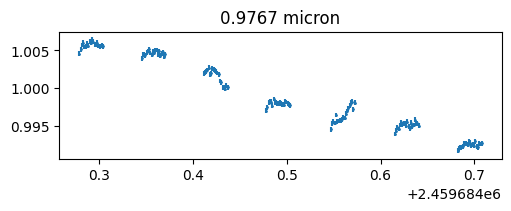

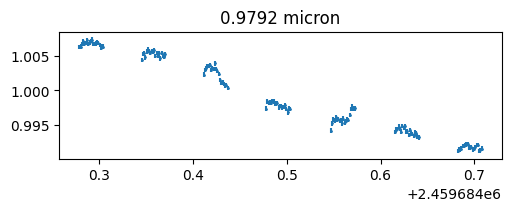

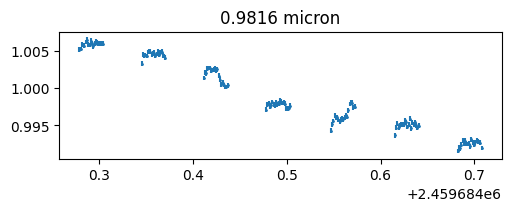

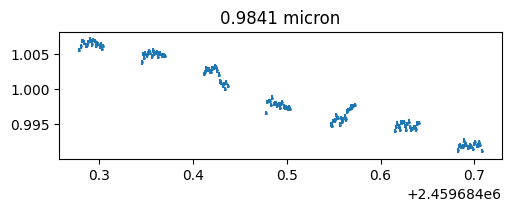

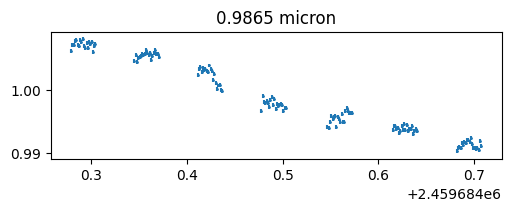

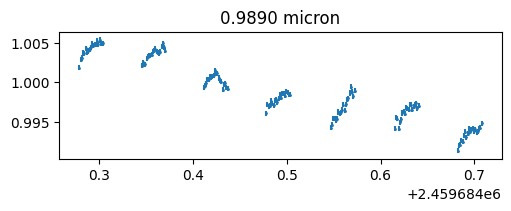

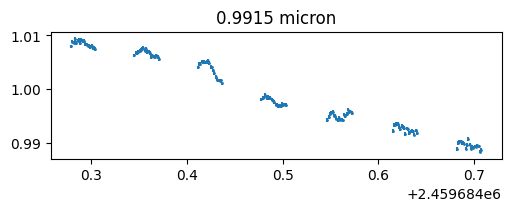

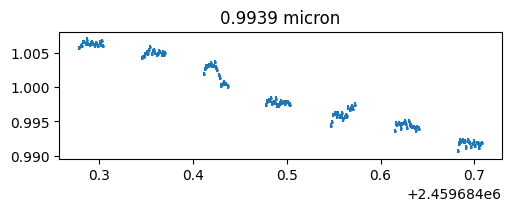

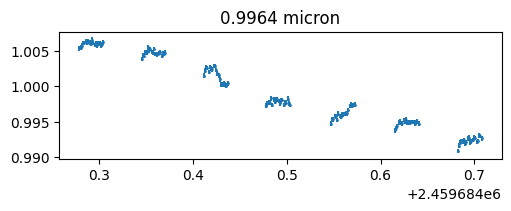

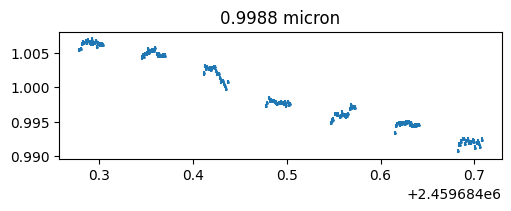

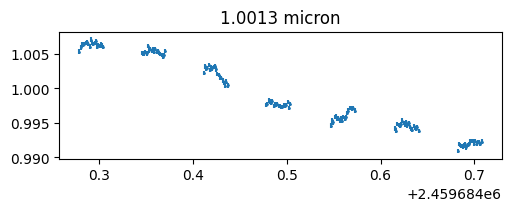

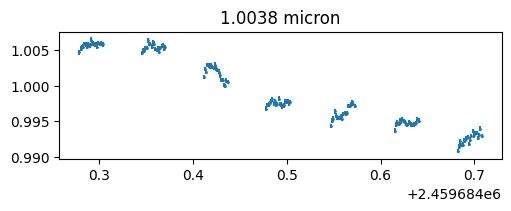

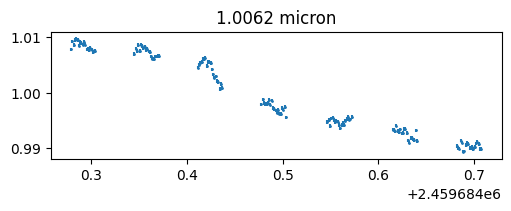

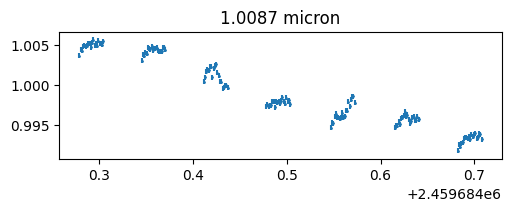

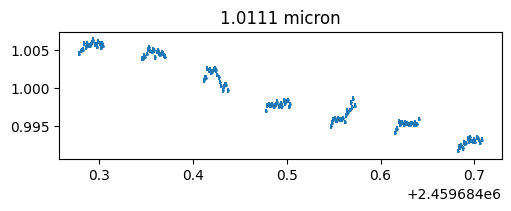

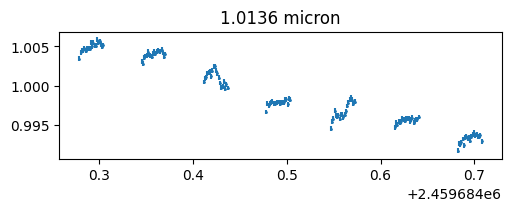

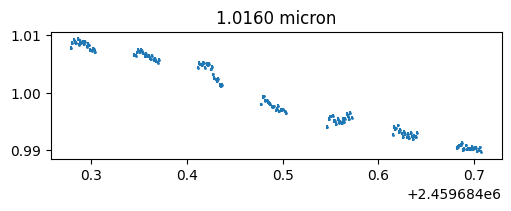

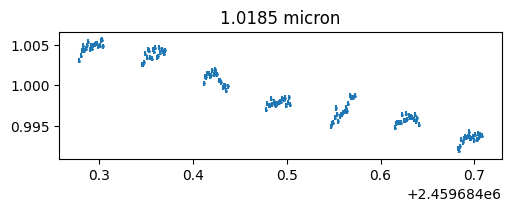

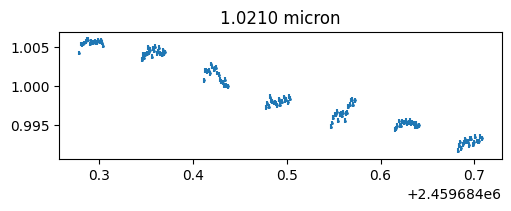

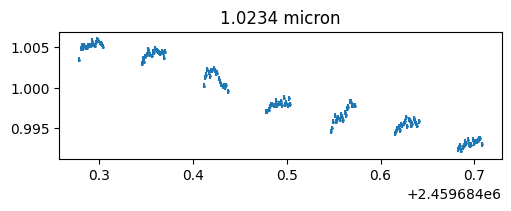

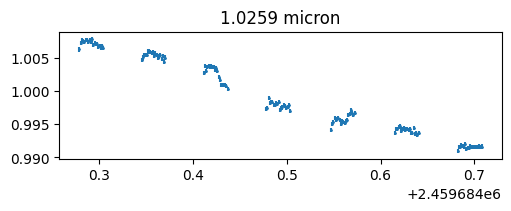

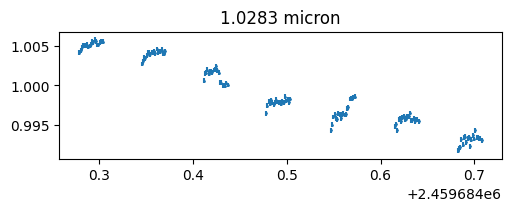

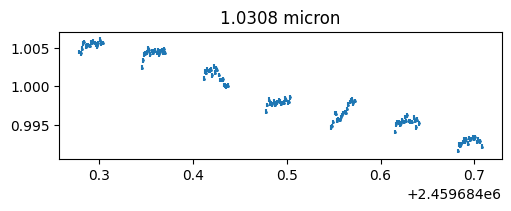

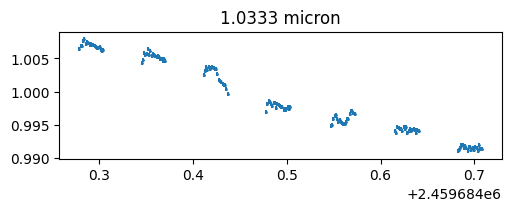

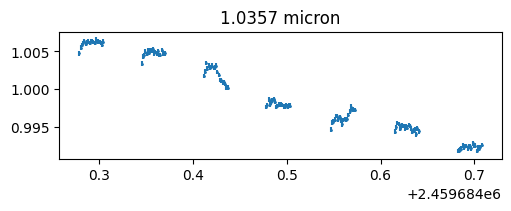

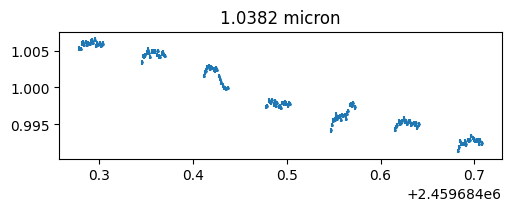

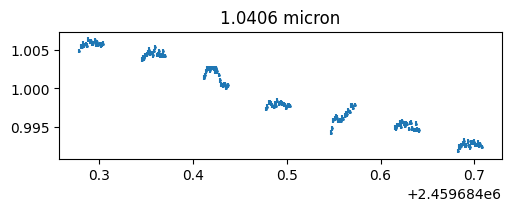

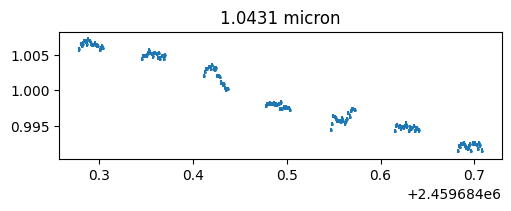

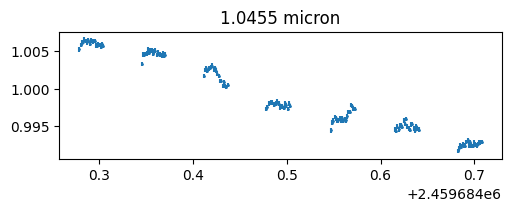

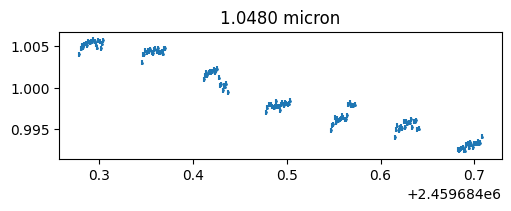

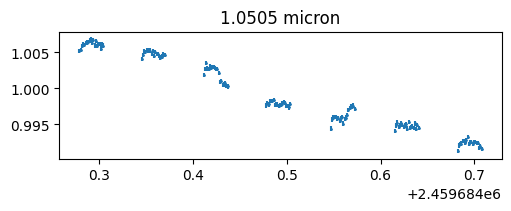

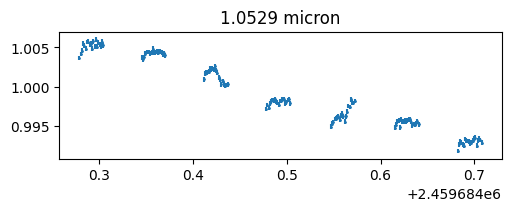

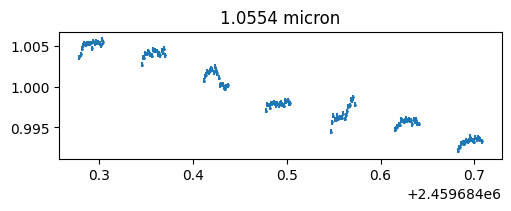

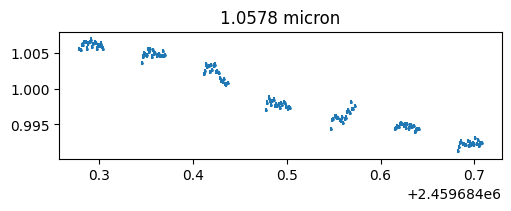

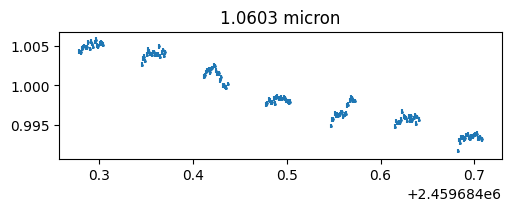

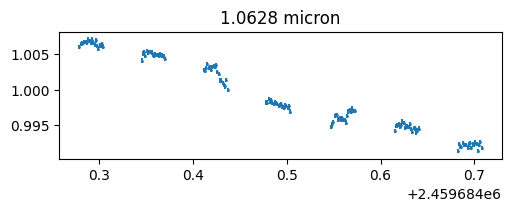

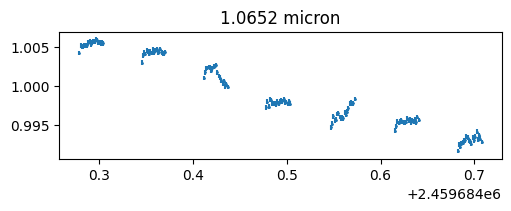

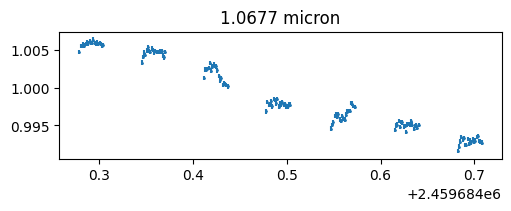

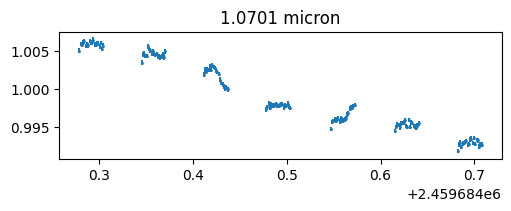

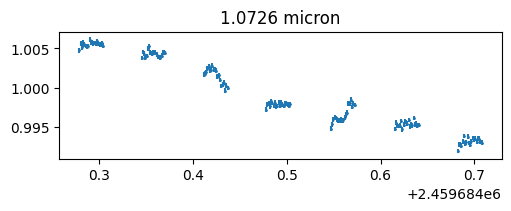

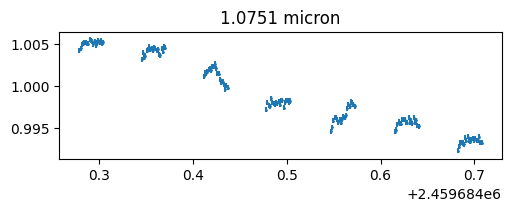

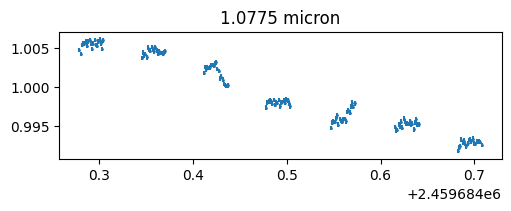

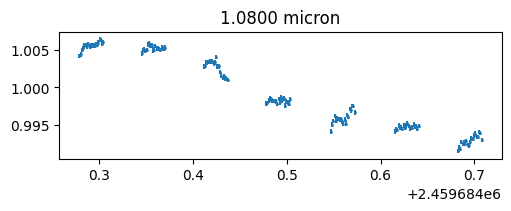

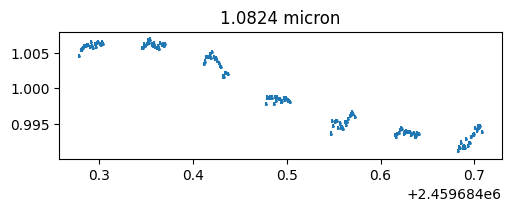

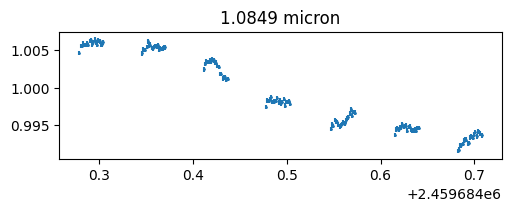

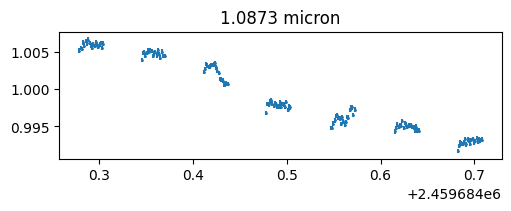

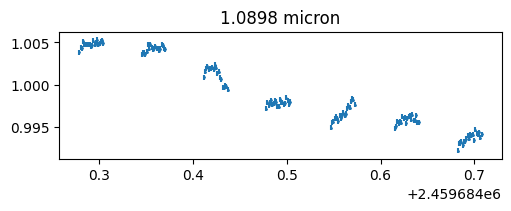

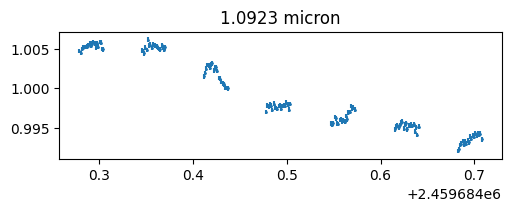

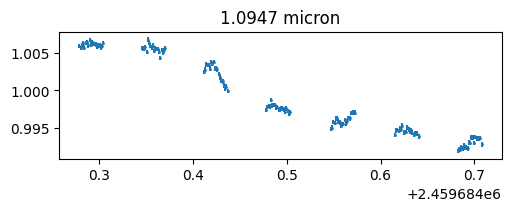

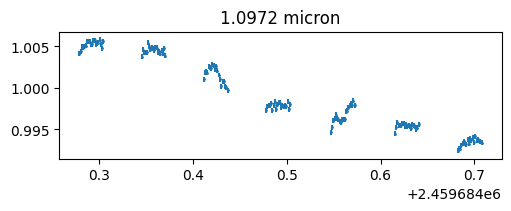

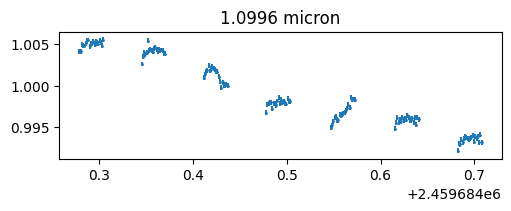

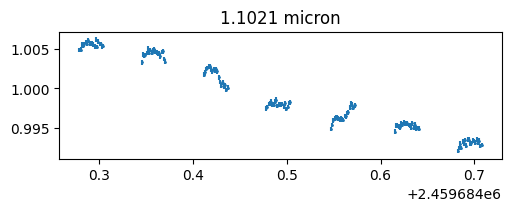

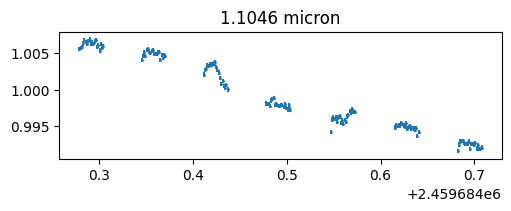

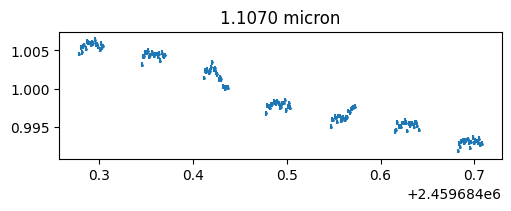

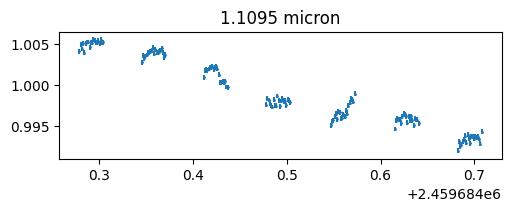

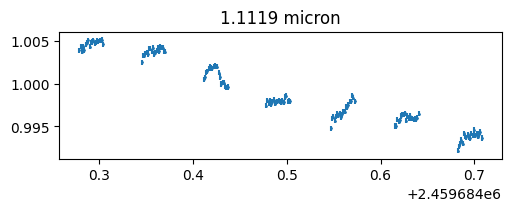

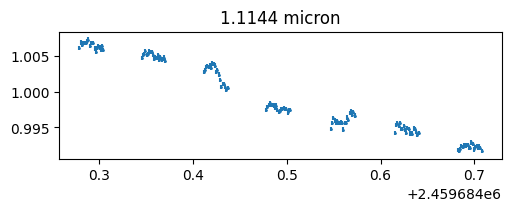

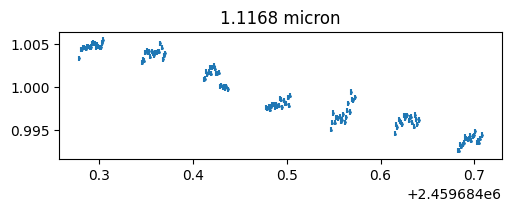

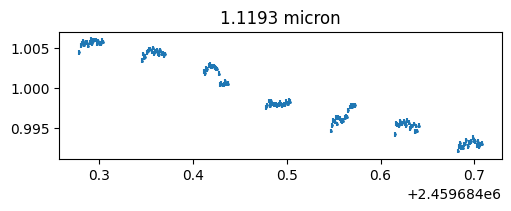

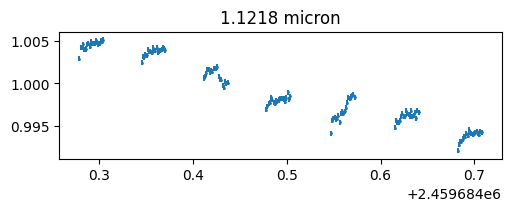

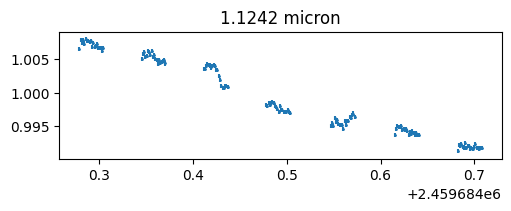

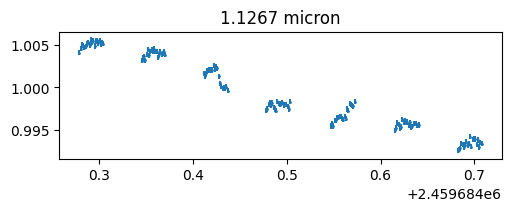

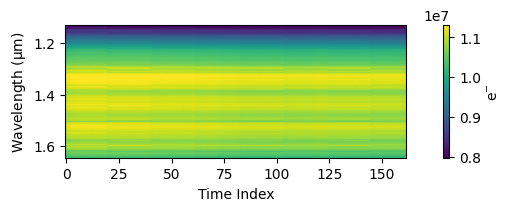

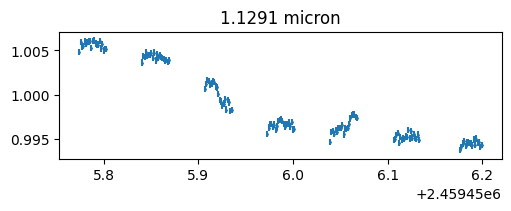

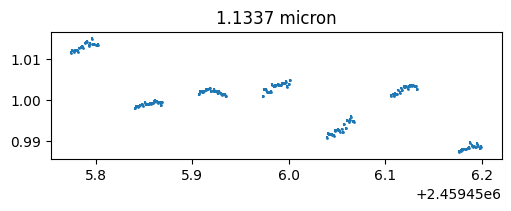

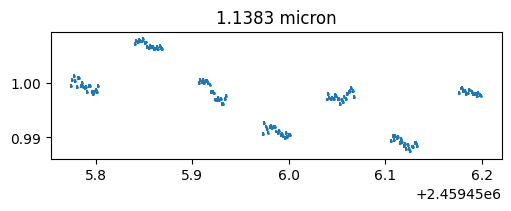

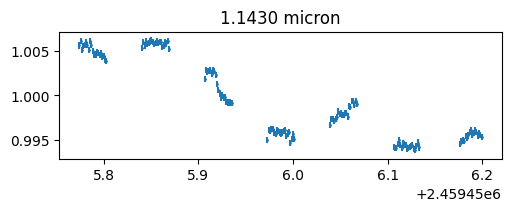

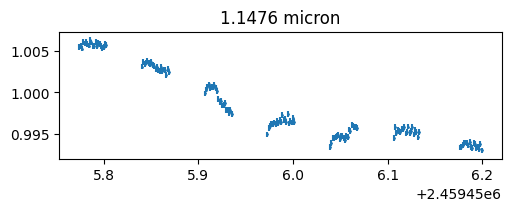

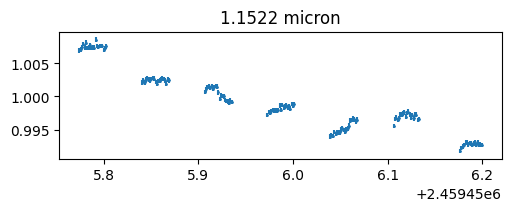

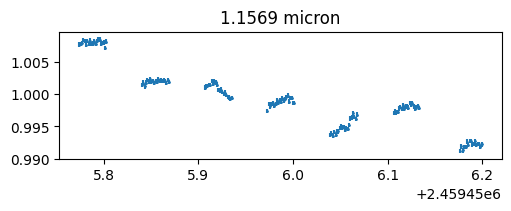

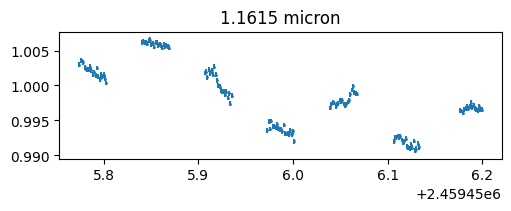

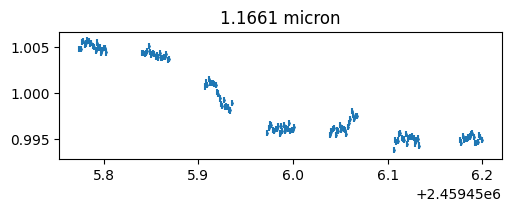

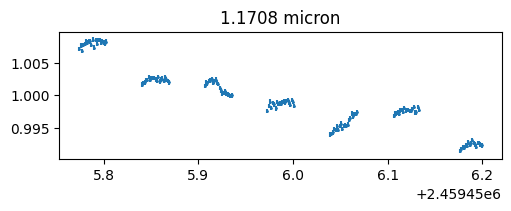

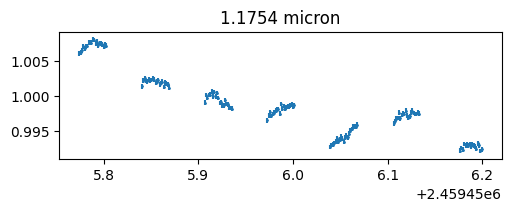

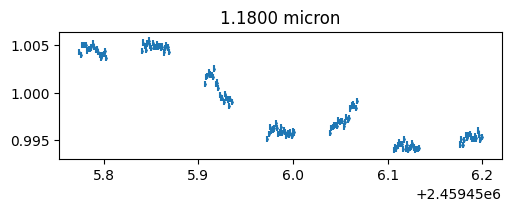

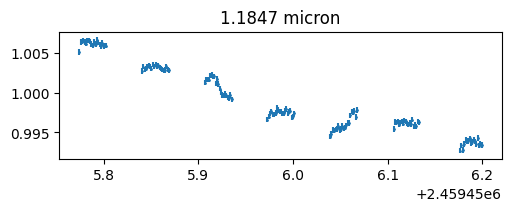

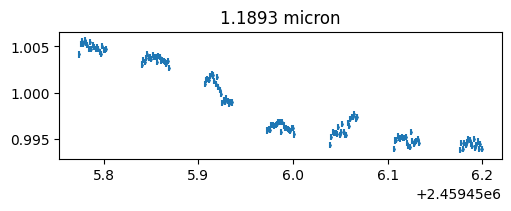

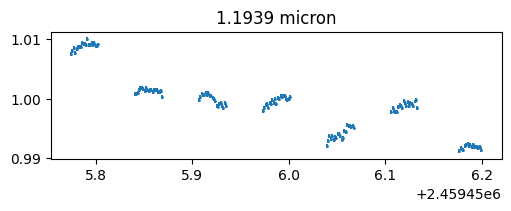

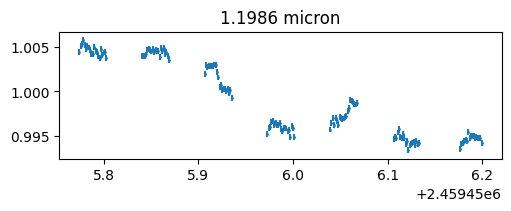

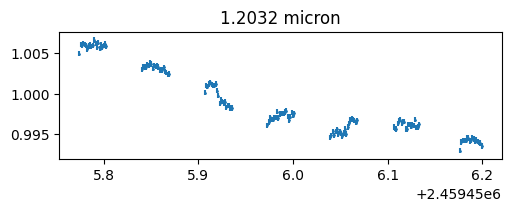

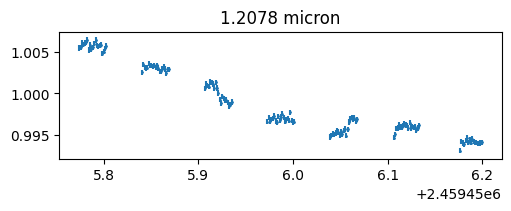

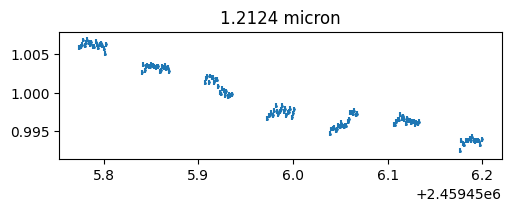

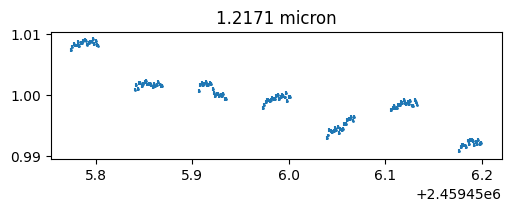

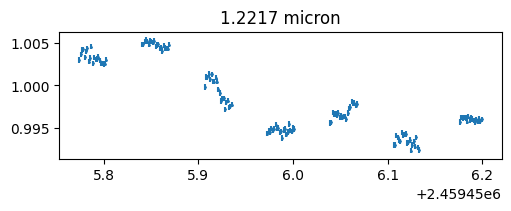

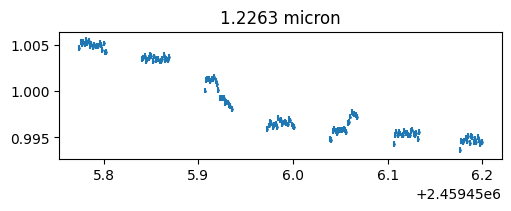

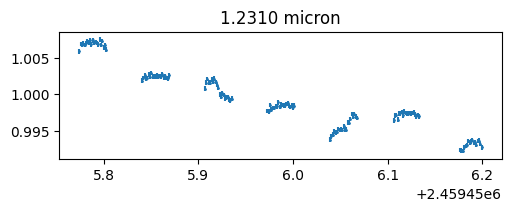

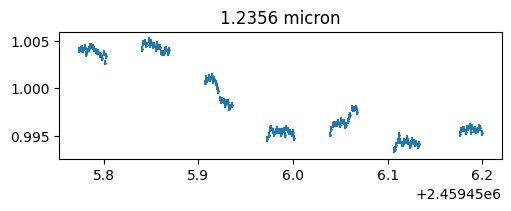

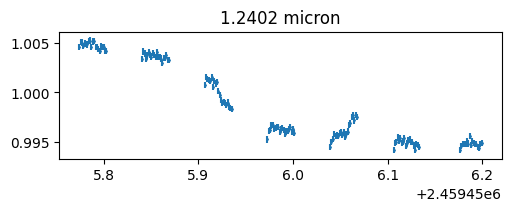

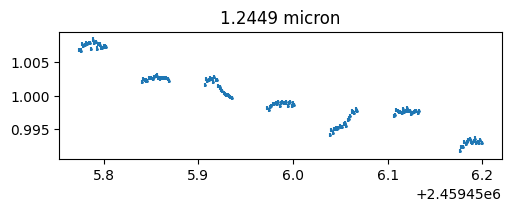

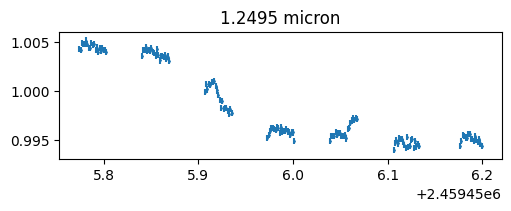

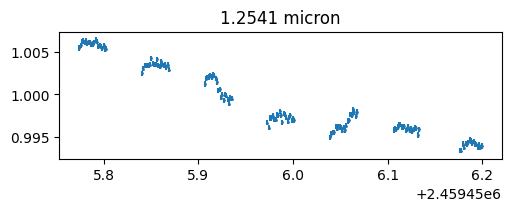

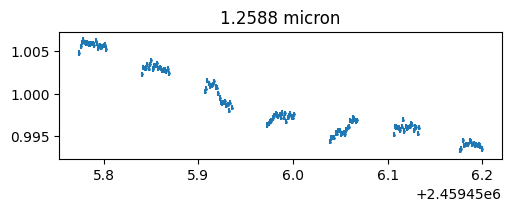

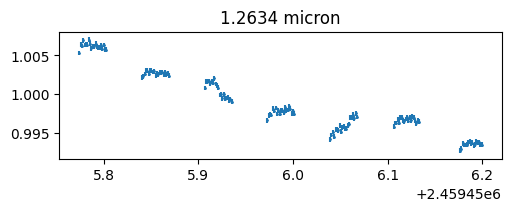

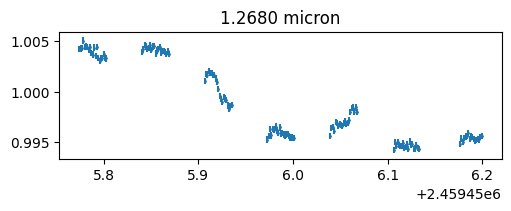

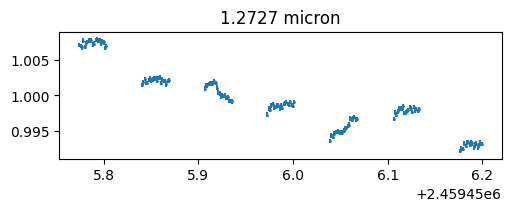

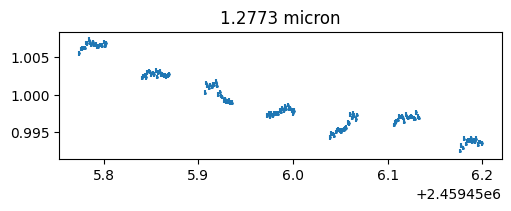

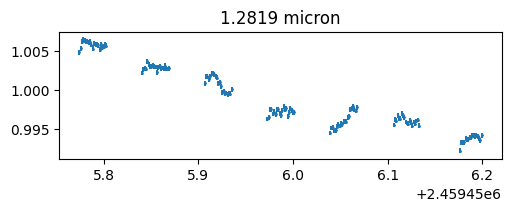

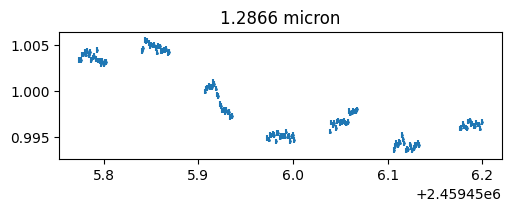

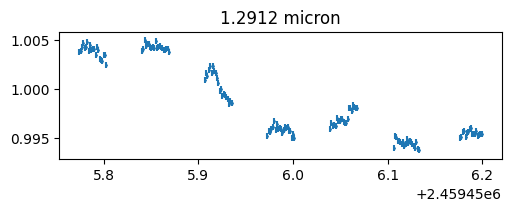

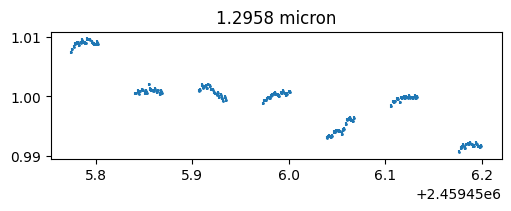

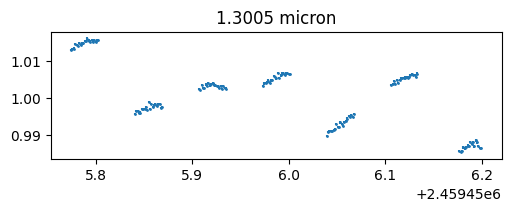

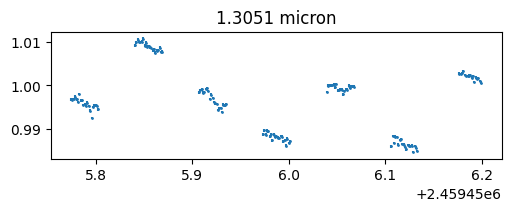

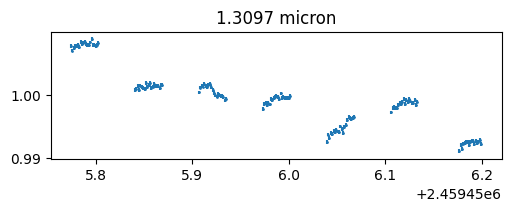

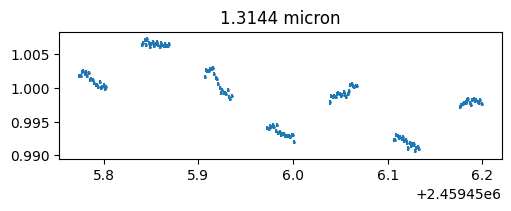

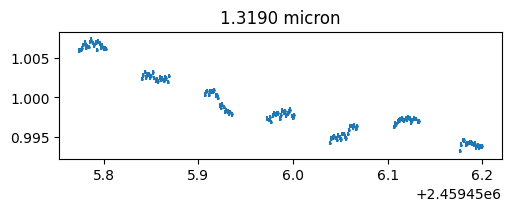

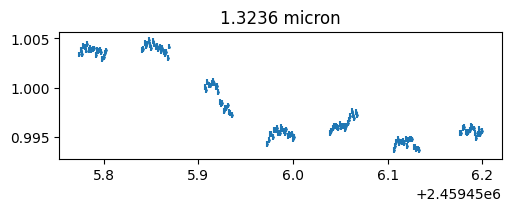

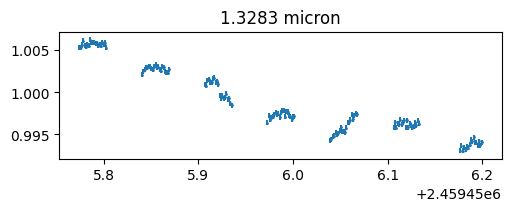

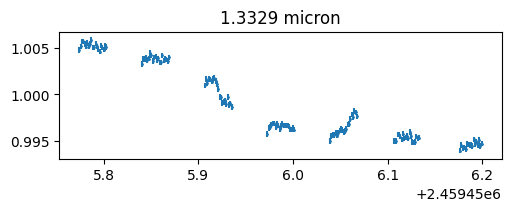

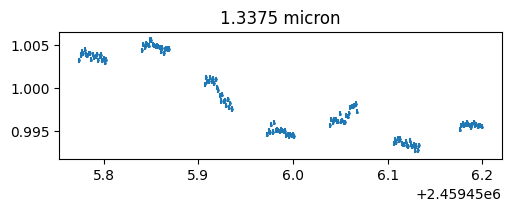

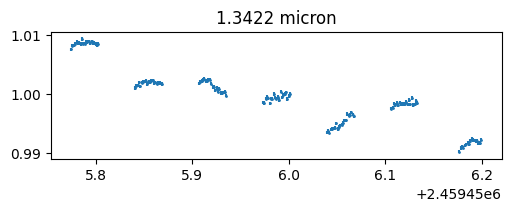

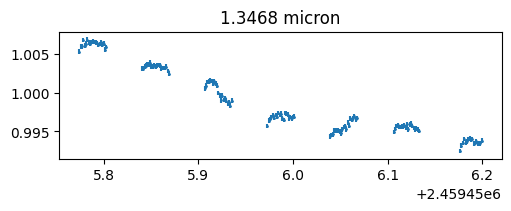

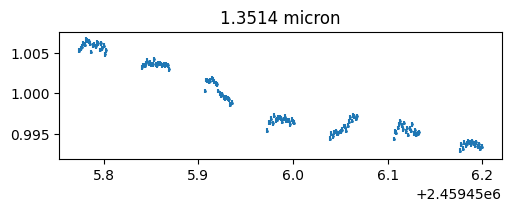

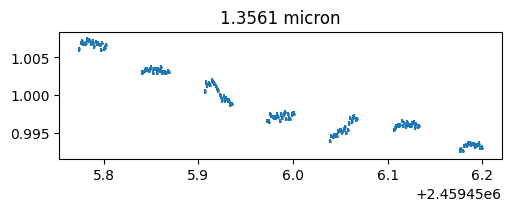

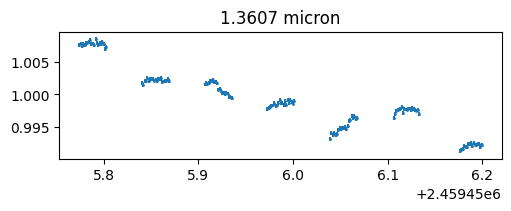

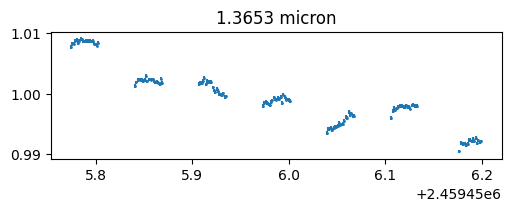

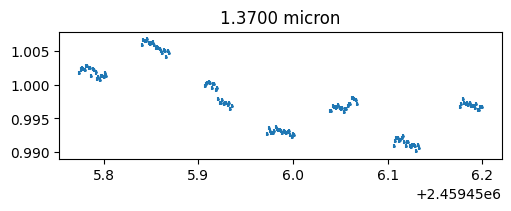

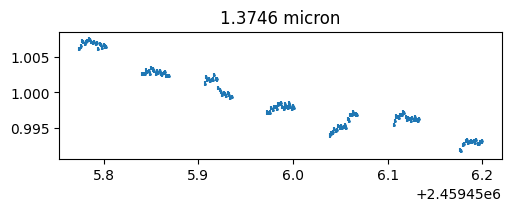

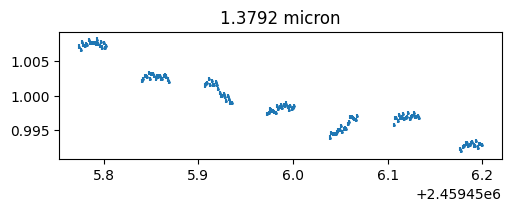

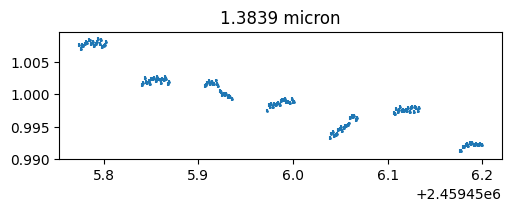

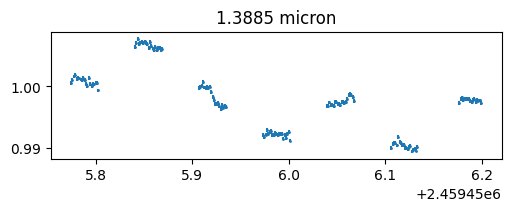

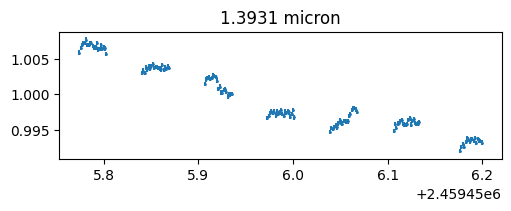

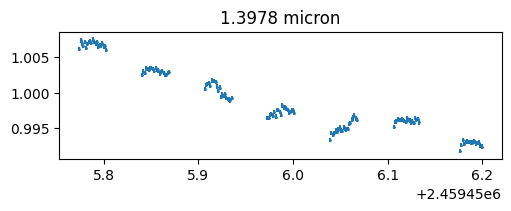

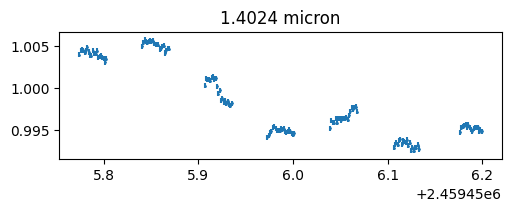

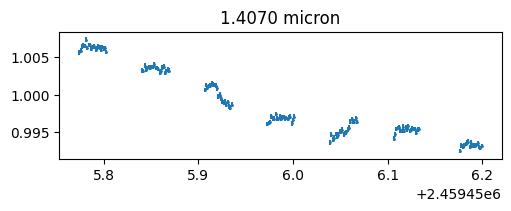

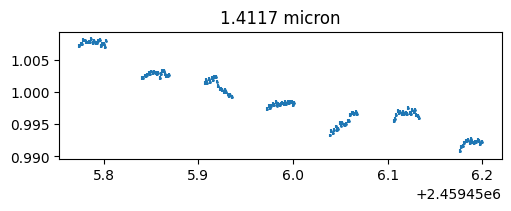

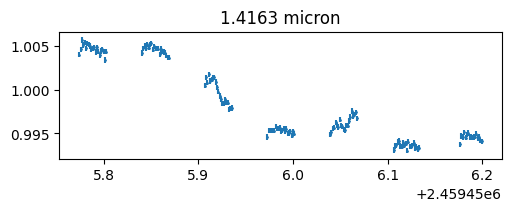

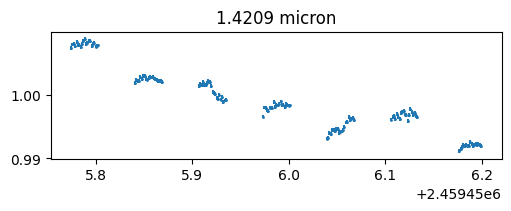

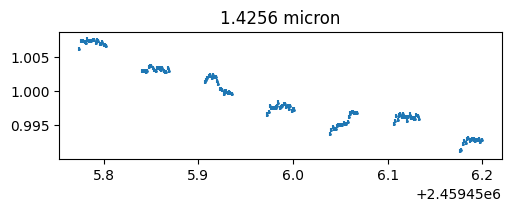

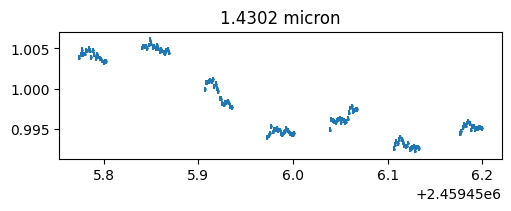

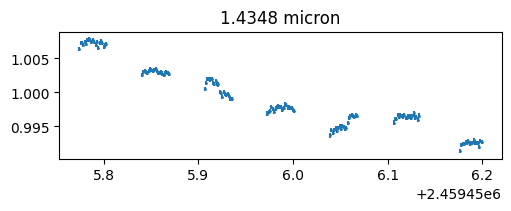

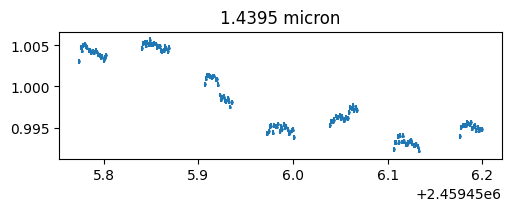

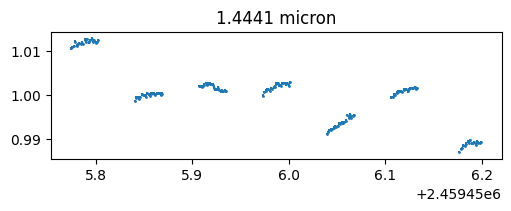

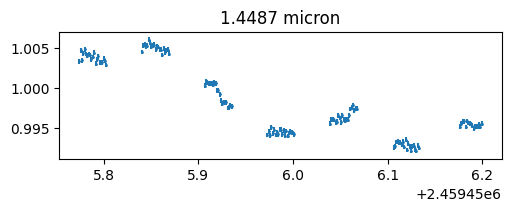

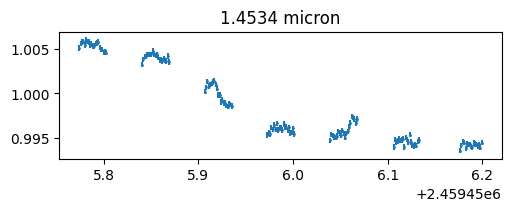

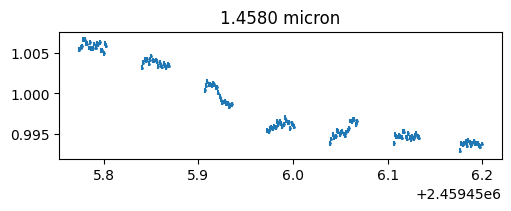

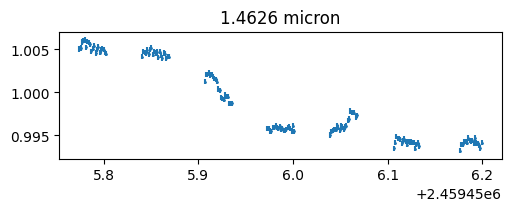

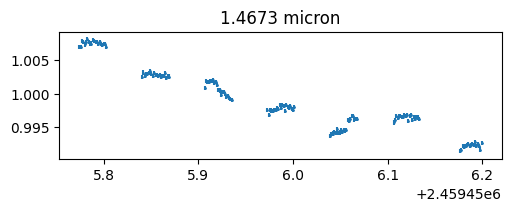

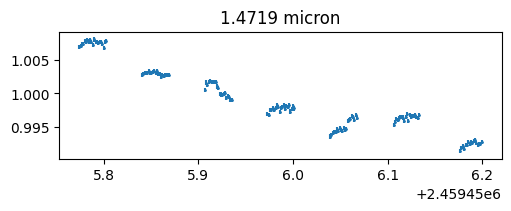

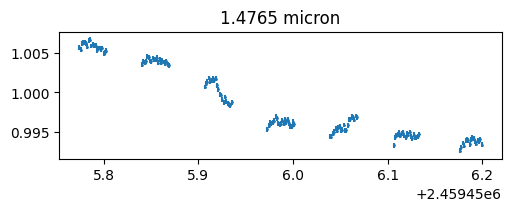

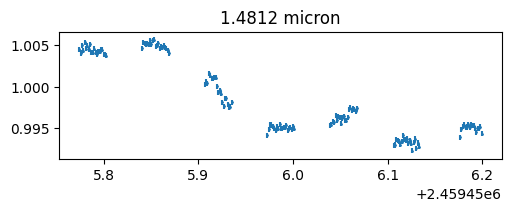

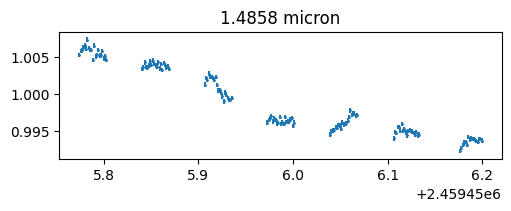

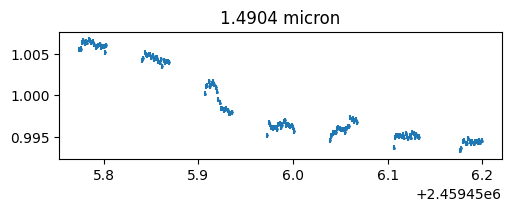

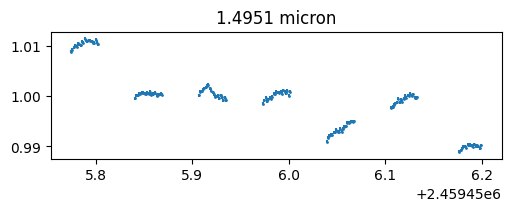

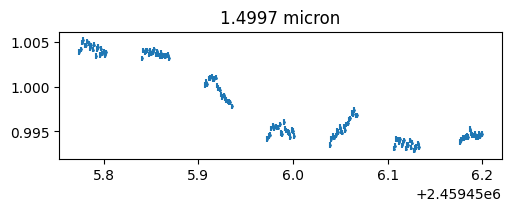

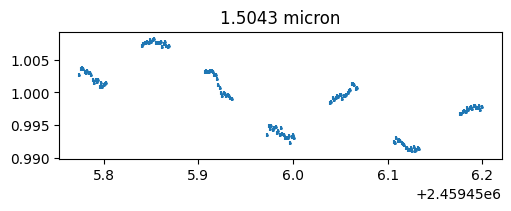

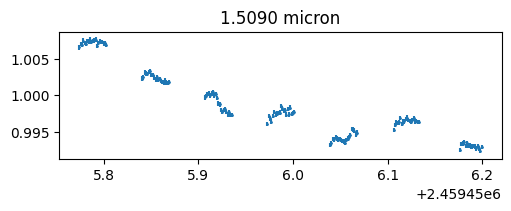

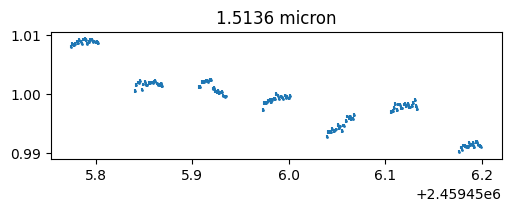

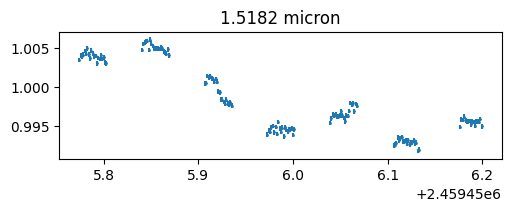

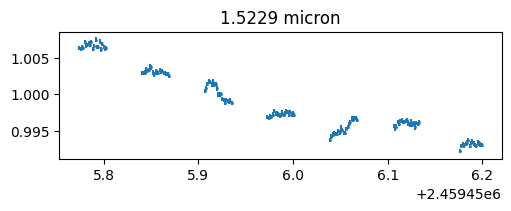

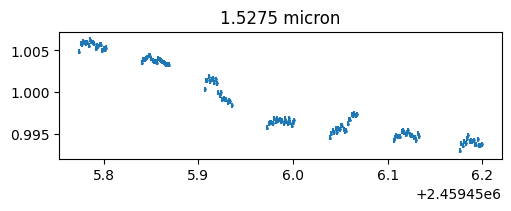

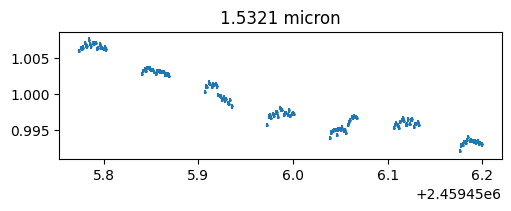

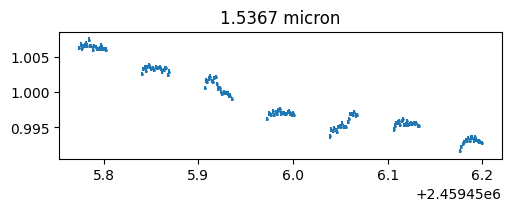

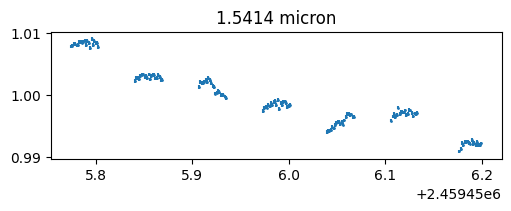

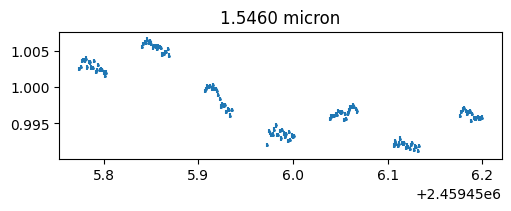

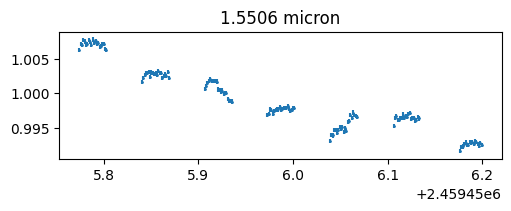

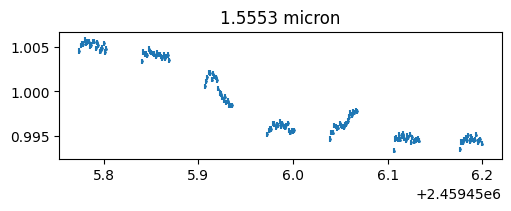

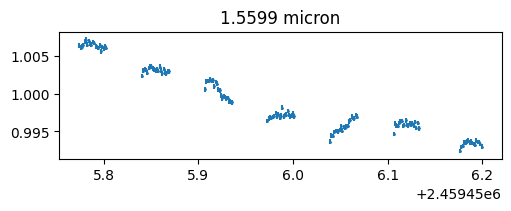

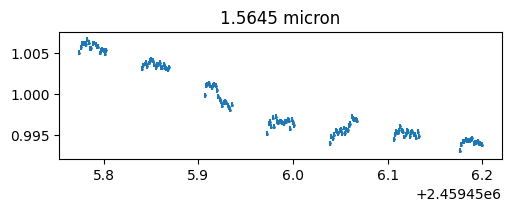

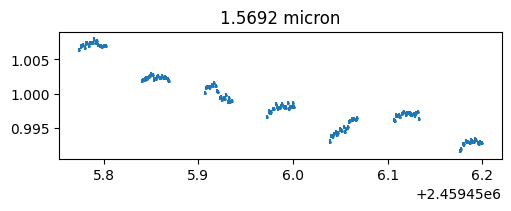

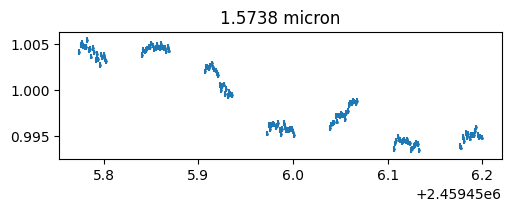

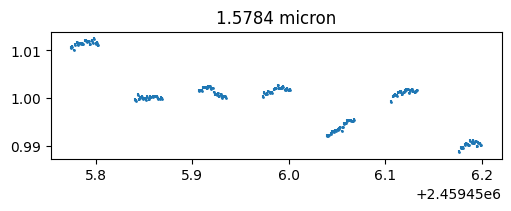

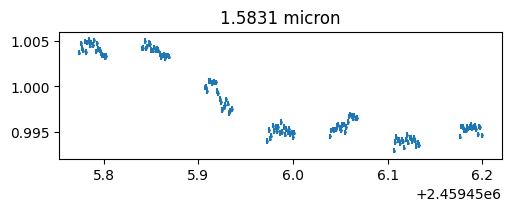

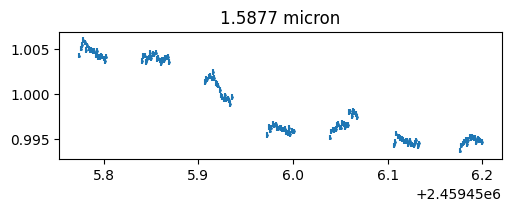

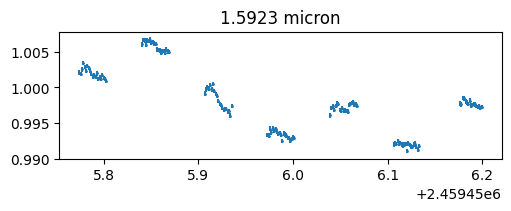

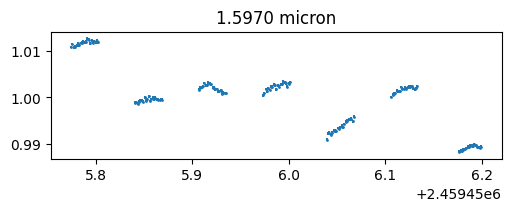

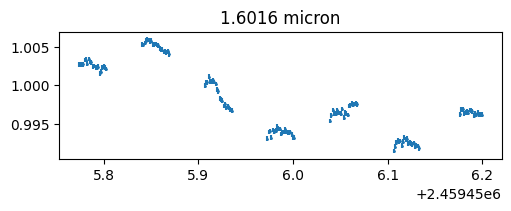

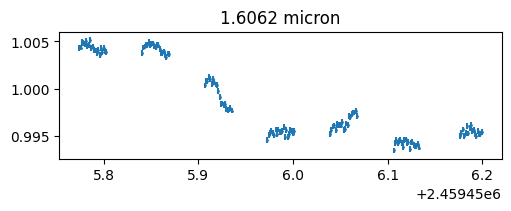

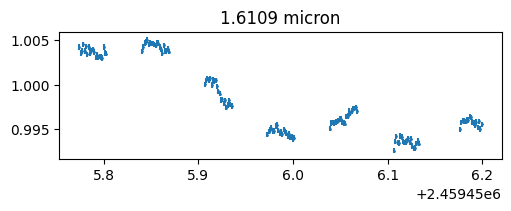

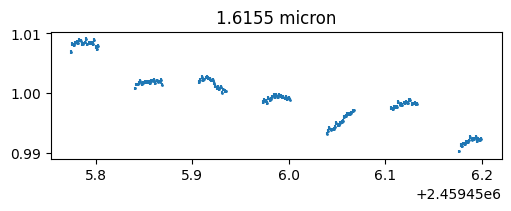

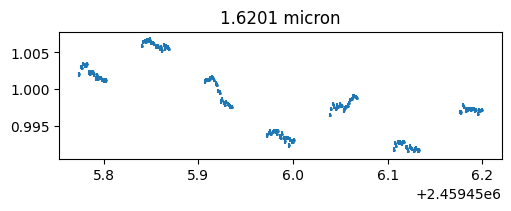

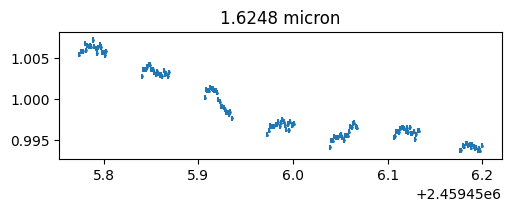

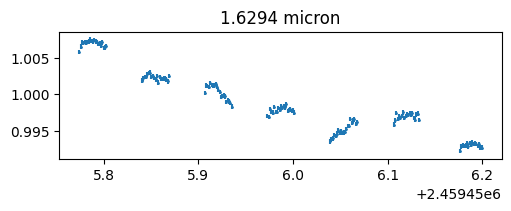

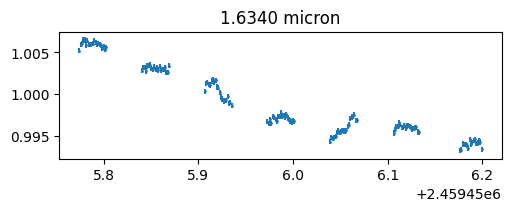

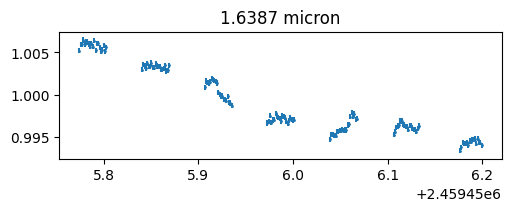

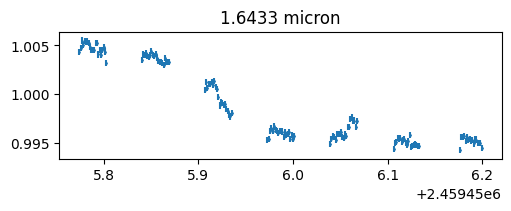

In [14]:
for visit in ['S22','F21']:

    # bin_edges = S22_bin_edges if visit == 'S22' else F21_bin_edges
    
    'Read in the trimmed rainbows from process_pacman_spectra.ipynb'
    data_fluxes = []
    spec_errs = []
    img_dates = []
    wave_arrays = []
    for direction in ['Forward','Reverse']:
        rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
        # rainbow = rainbow.bin(wavelength_edges = bin_edges)
        img_dates.append(rainbow.time.value)
        wave_arrays.append(rainbow.wavelength.value)
        data_fluxes.append(rainbow.flux.value)
        spec_errs.append(rainbow.uncertainty.value)
    data_wavelength = np.nanmean(wave_arrays, axis=0)
    img_date = np.nanmean(img_dates,axis=0)
    data_flux = np.nansum(data_fluxes,axis=0)
    data_err = np.sqrt(spec_errs[0]**2 + spec_errs[1]**2) * u.electron

    scan_combined_rainbow = Rainbow(wavelength=data_wavelength*u.micron, time=img_date*u.day, flux=data_flux * u.electron, uncertainty=data_err)
    scan_combined_rainbow.imshow()
    scan_combined_rainbow.save(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")

    relative_err =  np.sqrt(data_flux)/data_flux
    mean_data_flux = np.nanmean(data_flux, axis=1)
    normalized_data_flux = data_flux / mean_data_flux[:, np.newaxis]
    
    for i in range(len(data_wavelength)):
        print(f'{visit} | Median relative uncertainty at {data_wavelength[i]:.4f} micron = {int(np.nanmedian(relative_err[i,:])*1e6)} ppm')
        plt.figure(figsize = (5,2))
        plt.title(f'{data_wavelength[i]:.4f} micron')
        plt.errorbar(img_date[20:], normalized_data_flux[i,20:],relative_err[i,20:],fmt='o',ms=1)
    # processed = Rainbow(wavelength=data_wavelength*u.micron, time=img_date*u.day, flux=normalized_data_flux * u.dimensionless_unscaled, uncertainty=relative_err * u.dimensionless_unscaled)
    # processed.imshow()
    # processed.save(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")